# Multi-Label Intent Classification on Malaysian Online Forum Discussions
## Comparative Study: Logistic Regression vs. Linear Support Vector Classifier (Linear SVC)

Casual online forum comments written in **Bahasa Melayu**, **English**, and **Manglish** from Lowyat Kopitiam are classified according to the communicative purpose expressed by the user.

### The 6 Communicative Categories
- **Inquiry**: Questions, seeking help, recommendations, or troubleshooting.
- **Complaint**: Venting frustration, complaining about bad service, high prices, or problems.
- **Opinion**: Personal viewpoints, beliefs, reviews, or arguments.
- **Information**: Objective facts, news, official updates, guides, or links.
- **Expressive**: Jokes, laughing, memes, greetings, or casual banter.
- **Spam**: Unwanted promotional links, referral links, or automated bot posts.

A single forum comment may serve multiple communicative purposes; therefore, **Multi-Label Classification** is used.

# 0.0 Environment Setup & Configuration
Install and import all necessary dependencies, suppress non-critical warnings, and configure display options.

In [1]:
# Install dependencies if not already present
# !pip install -q nltk spacy malaya PySastrawi emoji contractions scikit-learn seaborn matplotlib tqdm joblib

import warnings
warnings.filterwarnings('ignore')
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

import re
import html
import json
import difflib
import emoji
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown, HTML
from tqdm.auto import tqdm
tqdm.pandas()

# Display and plotting settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', 1000)
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'

# Helper to print markdown in notebook output
def printmd(string):
    display(Markdown(string))

# Academic profanity / vulgarity masking helper for report figures
OFFENSIVE_TERMS = {
    'fuck', 'fucking', 'fucked', 'fucker', 'fuk',
    'shit', 'shitty', 'bullshit',
    'bitch', 'bastard', 'asshole', 'dick', 'pussy', 'penis', 'vagina', 'cock',
    'babi', 'puki', 'pukimak', 'pantek', 'lanjiao', 'lj', 'cibai', 'cb', 'sohai',
    'buto', 'butoh', 'kote', 'tetek', 'pepek', 'kimak', 'palatau', 'pundek',
    'anjing', 'sial', 'bangsat', 'celaka'
}

def mask_unpleasant_words(text):
    if not isinstance(text, str):
        return text
    def censor_match(m):
        w = m.group(0)
        if len(w) <= 2:
            return w[0] + '*'
        return w[0] + '*' * (len(w) - 1)
    censored_pattern = re.compile(r'\b(' + '|'.join(sorted(OFFENSIVE_TERMS, key=len, reverse=True)) + r')\b', flags=re.IGNORECASE)
    return censored_pattern.sub(censor_match, text)

printmd("**Environment initialized successfully.**")

**Environment initialized successfully.**

# Step 1: Load Dataset & Exploratory Data Analysis (EDA)
The annotated forum dataset (`dataset.csv`) is loaded to inspect total records, target intent distributions, average word count per communicative category, and multi-label intent combination co-occurrences.

### 1.1 Load Dataset & Preview Records
The raw CSV dataset is loaded into Pandas to inspect record count, schema, and sample forum comments.

In [2]:
# Load cleaned dataset from dataset.csv
dataset_path = 'dataset.csv'
df = pd.read_csv(dataset_path, encoding='utf-8')

target_cols = ['Inquiry', 'Complaint', 'Opinion', 'Information', 'Expressive', 'Spam']

printmd(f"**Dataset Summary:** `{len(df):,}` total rows, `{df.shape[1]}` columns")
printmd("#### Figure 3.2: Preview of First 5 Dataset Records")
display(df.head(5))

**Dataset Summary:** `99,103` total rows, `8` columns

#### Figure 3.2: Preview of First 5 Dataset Records

,id,text,Inquiry,Complaint,Opinion,Information,Expressive,Spam
0,1,the feast starts now!,0,0,0,0,1,0
1,2,Shake shake 5pm\n\nhttps://games.shopee.com.my/universal-link/...95515050372?f=1,0,0,0,1,0,1
2,3,Situasi dlm keta\n\nKau : padu betul\n\nDia : padu apa??\n\nKau : eh bkn..pandu betul betul,0,0,0,0,1,0
3,4,currently he is playing for india?\nwooooh.....tat's new,1,0,0,0,1,0
4,5,"QUOTE(ahmad92 @ Dec 17 2022, 01:03 PM)Oi apek, i bunuh empat player with low health in overpass you tak post. Hahaha\nManada. Tatau tatau 🤣🤣🤣🤣🤣🤣",0,0,0,0,1,0


### Figure 3.3: Complaint Labeled Post Example
Representative forum post categorized under **Complaint** expressing backward-looking consumer dissatisfaction.

In [3]:
printmd("#### Figure 3.3: Complaint Labeled Post Example")
sample_complaint = df[(df['Complaint'] == 1) & (df['text'].apply(lambda x: len(str(x)) > 30))][['id', 'text', 'Complaint', 'Opinion', 'Inquiry']].head(1)
display(sample_complaint)

#### Figure 3.3: Complaint Labeled Post Example

,id,text,Complaint,Opinion,Inquiry
6,7,"QUOTE(chilskater @ Dec 10 2020, 11:20 AM)this guy suka maki other's people first.... then said his job baru betul caranya....\nLast time i saw his video, he suggest to use many fans instead of aircon to stay cool indoor.. he use like 4 standfan acted like exhaust fan and pointed to outside of the house... but in the video he berpeluh2.... macam chee bye",1,1,0


### Figure 3.4: Pure Opinion Labeled Post Example
Representative forum post categorized exclusively under **Opinion** expressing subjective viewpoints without complaint grievances.

In [4]:
printmd("#### Figure 3.4: Pure Opinion Labeled Post Example")
sample_opinion = df[(df['Opinion'] == 1) & (df['Complaint'] == 0) & (df['Inquiry'] == 0) & (df['text'].apply(lambda x: len(str(x)) > 30))][['id', 'text', 'Opinion', 'Complaint', 'Information']].head(1)
display(sample_opinion)

#### Figure 3.4: Pure Opinion Labeled Post Example

,id,text,Opinion,Complaint,Information
5,6,"QUOTE(Angry Clerk @ Mar 10 2023, 05:50 PM)yes non can join, like DPPH PAS, but can't be AJK\nWhy aim high to be AJK? Setakat bell boys or waiters on site should be enough",1,0,1


### Figure 3.5: Raw Forum Post Samples with Noise and Code-Switching
Raw forum comment samples illustrating quotation artefacts, emoji strings, and multilingual code-switching.

In [5]:
printmd("#### Figure 3.5: Raw Forum Post Samples with Noise and Code-Switching")
# 1. Quote block artifact
sample_quote = df[df['text'].apply(lambda x: 'QUOTE(' in str(x).upper() or '[QUOTE' in str(x).upper())].head(1)

# 2. Emoji string (pure post with emoji, excluding quotes)
sample_emoji = df[df['text'].apply(lambda x: bool(emoji.emoji_count(str(x))) and 'QUOTE(' not in str(x).upper())].head(1)

# 3. Multilingual / Code-switching (Manglish/Malay mixing, excluding quotes and emojis)
sample_mixed = df[df['text'].apply(lambda x: bool(re.search(r'\b(padu|keta|bkn|pandu|dlm)\b', str(x), flags=re.IGNORECASE)) and 'QUOTE(' not in str(x).upper() and not emoji.emoji_count(str(x)))].head(1)

noise_samples_df = pd.concat([sample_quote, sample_emoji, sample_mixed])
display(noise_samples_df[['id', 'text']])

#### Figure 3.5: Raw Forum Post Samples with Noise and Code-Switching

,id,text
4,5,"QUOTE(ahmad92 @ Dec 17 2022, 01:03 PM)Oi apek, i bunuh empat player with low health in overpass you tak post. Hahaha\nManada. Tatau tatau 🤣🤣🤣🤣🤣🤣"
112,113,Globophobia 😵‍💫🎈
2,3,Situasi dlm keta\n\nKau : padu betul\n\nDia : padu apa??\n\nKau : eh bkn..pandu betul betul


### 1.2 Individual Intent Distribution & Average Post Length (Word Count)
Visualizes the overall distribution of the 6 communicative intent classes alongside the average post length (word count) for each intent category.

In [6]:
# Compute word count for each post
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))

intent_stats = []
for intent in target_cols:
    subset = df[df[intent] == 1]
    intent_stats.append({
        'Intent Category': intent,
        'Total Posts': len(subset),
        'Dataset Prevalence (%)': f"{len(subset) / len(df) * 100:.2f}%",
        'Average Word Count': round(subset['word_count'].mean(), 2),
        'Median Word Count': int(subset['word_count'].median()),
        'Min Word Count': subset['word_count'].min(),
        'Max Word Count': subset['word_count'].max()
    })

intent_stats_df = pd.DataFrame(intent_stats)
printmd("#### Intent Class Distributions & Post Length Statistics:")
display(intent_stats_df)

#### Intent Class Distributions & Post Length Statistics:

,Intent Category,Total Posts,Dataset Prevalence (%),Average Word Count,Median Word Count,Min Word Count,Max Word Count
0,Inquiry,21684,21.88%,41.24,26,1,1352
1,Complaint,24718,24.94%,54.23,34,1,2003
2,Opinion,58735,59.27%,45.28,28,1,2104
3,Information,33875,34.18%,58.32,33,1,6742
4,Expressive,26702,26.94%,27.29,16,1,2003
5,Spam,4926,4.97%,15.71,6,1,6742


### 1.3 Target Intent Class Distributions (Bar Charts & Tables)
Visualizes overall class frequencies across the dataset.

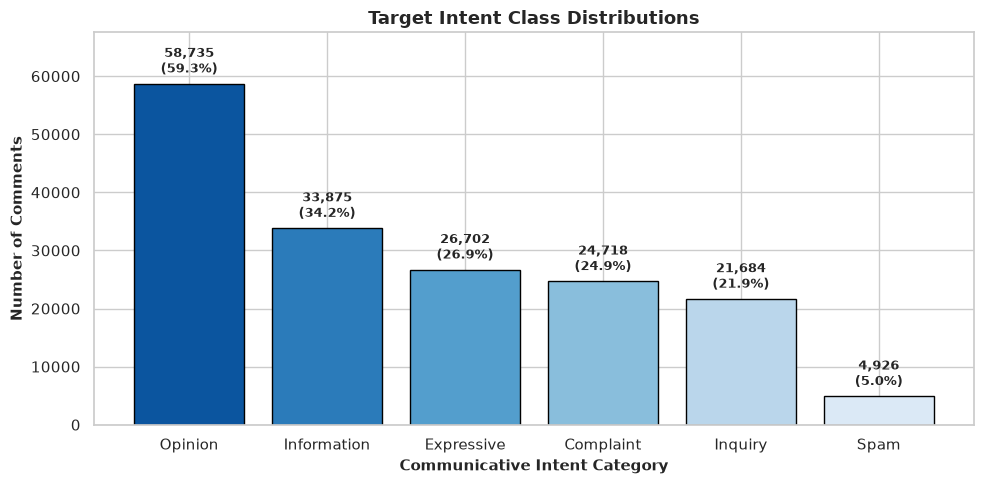

In [7]:
# Plot individual intent class distribution
intent_counts = df[target_cols].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
bars = plt.bar(intent_counts.index, intent_counts.values, color=sns.color_palette("Blues_r", len(intent_counts)), edgecolor='black')
plt.title("Target Intent Class Distributions", fontsize=13, fontweight='bold')
plt.xlabel("Communicative Intent Category", fontsize=11, fontweight='bold')
plt.ylabel("Number of Comments", fontsize=11, fontweight='bold')
plt.ylim(0, max(intent_counts.values) * 1.15)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + max(intent_counts.values)*0.02, f"{int(yval):,}\n({yval/len(df)*100:.1f}%)", ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

### 1.4 Multi-Label Intent Combinations (Co-occurrence Matrix & Breakdown Table)
Analyzes co-occurrence patterns between multi-label intent pairs across the forum corpus.

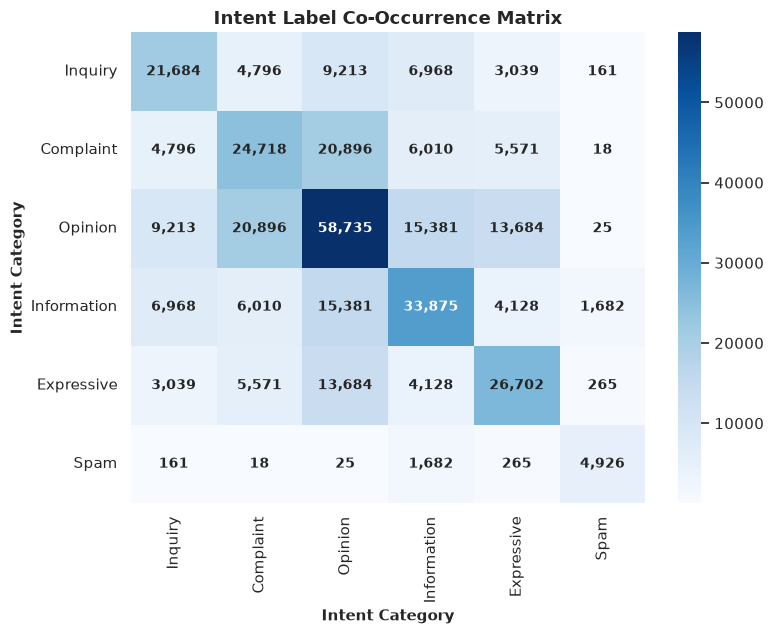

In [8]:
# Multi-label co-occurrence matrix
co_occurrence = df[target_cols].T.dot(df[target_cols])

plt.figure(figsize=(8, 6.5))
sns.heatmap(co_occurrence, annot=True, fmt=',d', cmap='Blues', cbar=True, annot_kws={"size": 10, "fontweight": "bold"})
plt.title("Intent Label Co-Occurrence Matrix", fontsize=13, fontweight='bold')
plt.xlabel("Intent Category", fontsize=11, fontweight='bold')
plt.ylabel("Intent Category", fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

# Create intent combination signature per row
def get_intent_combination(row):
    active = [col for col in target_cols if row[col] == 1]
    return ' + '.join(active) if active else 'None'
    
df['intent_combination'] = df.apply(get_intent_combination, axis=1)

### 1.5 Top 10 & Complete Breakdown of Intent Combinations Including Opinion, Inquiry, and Spam

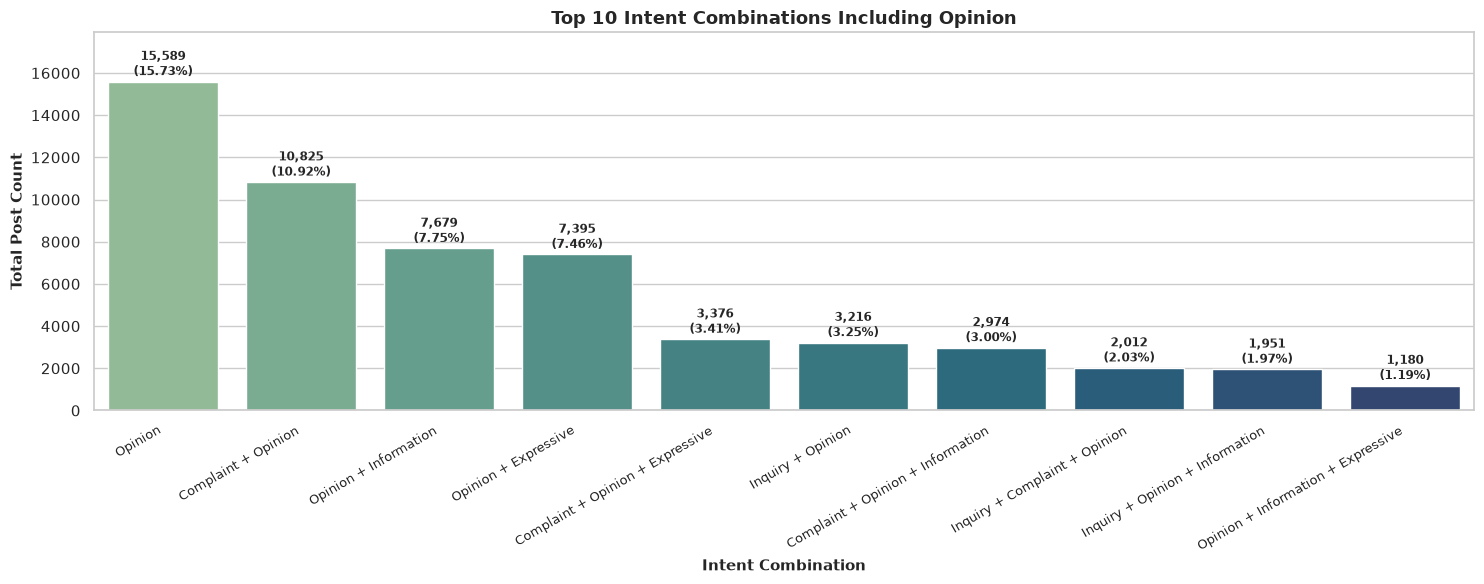

In [9]:
# Combinations including Opinion
opinion_combinations = df[df['Opinion'] == 1]['intent_combination'].value_counts()
top_10_opinion = opinion_combinations.head(10)

plt.figure(figsize=(15, 6))
sns.barplot(x=top_10_opinion.index, y=top_10_opinion.values, palette="crest")
plt.title("Top 10 Intent Combinations Including Opinion", fontsize=13, fontweight='bold')
plt.xlabel("Intent Combination", fontsize=11, fontweight='bold')
plt.ylabel("Total Post Count", fontsize=11, fontweight='bold')
plt.ylim(0, top_10_opinion.values[0] * 1.15)
plt.xticks(rotation=30, ha='right', fontsize=9.5)
for i, v in enumerate(top_10_opinion.values):
    plt.text(i, v + top_10_opinion.values[0]*0.02, f"{v:,}\n({v/len(df)*100:.2f}%)", ha='center', fontsize=8.5, fontweight='bold')
plt.tight_layout()
plt.show()

### 1.6 Top 10 & Complete Breakdown of Intent Combinations Including Expressive, Information, and Complaint

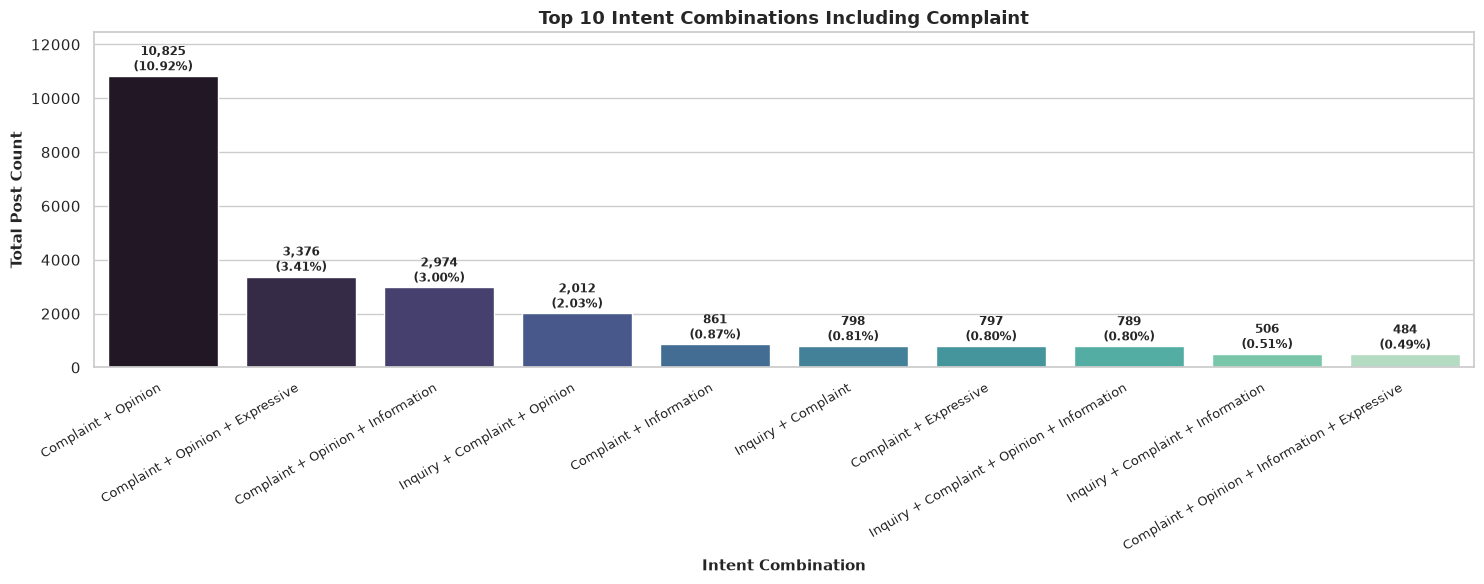

In [10]:
# Combinations including Complaint
complaint_combinations = df[df['Complaint'] == 1]['intent_combination'].value_counts()
top_10_complaint = complaint_combinations.head(10)

plt.figure(figsize=(15, 6))
sns.barplot(x=top_10_complaint.index, y=top_10_complaint.values, palette="mako")
plt.title("Top 10 Intent Combinations Including Complaint", fontsize=13, fontweight='bold')
plt.xlabel("Intent Combination", fontsize=11, fontweight='bold')
plt.ylabel("Total Post Count", fontsize=11, fontweight='bold')
plt.ylim(0, top_10_complaint.values[0] * 1.15)
plt.xticks(rotation=30, ha='right', fontsize=9.5)
for i, v in enumerate(top_10_complaint.values):
    plt.text(i, v + top_10_complaint.values[0]*0.02, f"{v:,}\n({v/len(df)*100:.2f}%)", ha='center', fontsize=8.5, fontweight='bold')
plt.tight_layout()
plt.show()

## 2. Text Preprocessing Pipeline
### Preprocessing Change Inspection Helper (Visual Colored HTML Diff View)
We define `show_step_diff()` using Python's `difflib.SequenceMatcher` and `html.escape()` to render clean, 5-sample HTML diff views with `Row ID` (referencing the dataset primary key `id`), `BEFORE (Prior Step)`, and `AFTER (Modified Step)`.

In [11]:
import difflib
import html

def show_step_diff(prev_series, curr_series, step_name):
    diff_mask = prev_series.apply(lambda x: str(x).split()) != curr_series.apply(lambda x: str(x).split())
    total_affected = diff_mask.sum()
    printmd(f"**[{step_name}]** Rows updated: `{total_affected:,}` ({total_affected/len(prev_series)*100:.4f}%)")
    
    if total_affected == 0:
        printmd("_No rows modified in this step._")
        return
        
    changed_df = pd.DataFrame({
        "id": df.loc[prev_series[diff_mask].index, "id"],
        "before": prev_series[diff_mask],
        "after": curr_series[diff_mask]
    })
    
    # Prioritize concise representative posts (< 250 chars), but always guarantee 5 samples if available
    short_samples = changed_df[changed_df["before"].apply(lambda x: len(str(x)) < 250)]
    remaining_samples = changed_df[~changed_df.index.isin(short_samples.index)]
    sample_df = pd.concat([short_samples, remaining_samples]).head(5) if len(changed_df) >= 5 else changed_df
    
    html_rows = []
    for idx, row in sample_df.iterrows():
        b_words = str(row["before"]).split()
        a_words = str(row["after"]).split()
        matcher = difflib.SequenceMatcher(None, b_words, a_words)
        
        b_out, a_out = [], []
        for tag, i1, i2, j1, j2 in matcher.get_opcodes():
            b_chunk = html.escape(" ".join(b_words[i1:i2]))
            a_chunk = html.escape(" ".join(a_words[j1:j2]))
            
            if tag == 'equal':
                b_out.append(b_chunk)
                a_out.append(a_chunk)
            elif tag == 'replace':
                b_out.append(f"<span style='background-color:#ffebee; color:#c62828; text-decoration:line-through;'>{b_chunk}</span>")
                a_out.append(f"<span style='background-color:#e8f5e9; color:#2e7d32; font-weight:bold;'>{a_chunk}</span>")
            elif tag == 'delete':
                b_out.append(f"<span style='background-color:#ffebee; color:#c62828; text-decoration:line-through;'>{b_chunk}</span>")
            elif tag == 'insert':
                a_out.append(f"<span style='background-color:#e8f5e9; color:#2e7d32; font-weight:bold;'>{a_chunk}</span>")
                
        row_id_label = f"Row {int(row['id'])}"
        html_rows.append(f'''
        <tr style="border-bottom: 1px solid #e0e0e0;">
            <td style="padding: 8px 6px; font-weight: bold; vertical-align: top; width: 8%; color: #555; text-align: left; word-break: break-word;">{row_id_label}</td>
            <td style="padding: 8px 10px; vertical-align: top; width: 46%; font-family: monospace; font-size: 12px; line-height: 1.5; text-align: left; word-break: break-word; white-space: normal;">{' '.join(b_out)}</td>
            <td style="padding: 8px 10px; vertical-align: top; width: 46%; font-family: monospace; font-size: 12px; line-height: 1.5; text-align: left; word-break: break-word; white-space: normal;">{' '.join(a_out)}</td>
        </tr>
        ''')
        
    table_html = f'''
<table style="table-layout: fixed; width: 100%; border-collapse: collapse; border: 1px solid #ccc; margin-top: 8px; margin-bottom: 16px;">
    <thead>
        <tr style="background-color: #f5f5f5; border-bottom: 2px solid #ccc; text-align: left;">
            <th style="width: 8%; padding: 8px 6px; font-size: 12px; text-align: left;">Row ID</th>
            <th style="width: 46%; padding: 8px 10px; font-size: 12px; text-align: left;">BEFORE (Prior Step)</th>
            <th style="width: 46%; padding: 8px 10px; font-size: 12px; text-align: left;">AFTER (Modified Step)</th>
        </tr>
    </thead>
    <tbody>
        {''.join(html_rows)}
    </tbody>
</table>
'''
    display(HTML(table_html))

# Initialize clean_text column
df['clean_text'] = df['text'].copy()

# Step 1: Remove Lowyat Quotes, BBCode, Signatures, and HTML
### Figure 3.6: Preprocessing Step 1 Removal of Forum Platform Markup
Forum-specific noise such as nested quote blocks, spoilers, images, BBCode tags, Lowyat edit signatures, and strict HTML markup are stripped.

In [12]:
def remove_quote_blocks(text):
    if not isinstance(text, str): return ""
    text = re.sub(r'\[quote(?:=[^\]]*)?\][\s\S]*?\[/quote\]', ' ', text, flags=re.IGNORECASE)
    text = re.sub(r'\[/?quote(?:=[^\]]*)?\]', ' ', text, flags=re.IGNORECASE)
    text = re.sub(r'\[/?quote\b', ' ', text, flags=re.IGNORECASE)
    text = re.sub(r'QUOTE\s*\([^\)]*?\)', ' ', text, flags=re.IGNORECASE)
    return text

def remove_spoilers(text):
    if not isinstance(text, str): return ""
    return re.sub(r'\[spoiler(?:=[^\]]*)?\][\s\S]*?\[/spoiler\]|\[/?spoiler(?:=[^\]]*)?\]', ' ', text, flags=re.IGNORECASE)

def remove_images_and_code(text):
    if not isinstance(text, str): return ""
    text = re.sub(r'\[img(?:=[^\]]*)?\][\s\S]*?\[/img\]|\[/?img(?:=[^\]]*)?\]', ' ', text, flags=re.IGNORECASE)
    text = re.sub(r'\[code(?:=[^\]]*)?\][\s\S]*?\[/code\]|\[/?code(?:=[^\]]*)?\]', ' ', text, flags=re.IGNORECASE)
    return text

def remove_media_bbcode(text):
    if not isinstance(text, str): return ""
    text = re.sub(r'\[attachmentid=[^\]]*\]|\[attachment=[^\]]*\]|\[/attachment\]', ' ', text, flags=re.IGNORECASE)
    text = re.sub(r'\[youtube(?:=[^\]]*)?\][\s\S]*?\[/youtube\]|\[/?youtube(?:=[^\]]*)?\]', ' ', text, flags=re.IGNORECASE)
    text = re.sub(r'\[video(?:=[^\]]*)?\][\s\S]*?\[/video\]|\[/?video(?:=[^\]]*)?\]', ' ', text, flags=re.IGNORECASE)
    text = re.sub(r'\[url=[^\]]*\]|\[/url\]|\[url\]', ' ', text, flags=re.IGNORECASE)
    return text

def remove_formatting_tags(text):
    if not isinstance(text, str): return ""
    return re.sub(r'\[/?(?:b|i|u|s|color|size|font|align|list|\*|center|left|right|sub|sup|table|tr|td|th)(?:=[^\]]*)?\]', ' ', text, flags=re.IGNORECASE)
    
def remove_signatures_and_redactions(text):
    if not isinstance(text, str): return ""
    text = re.sub(r'--+\s*\n[\s\S]*$', ' ', text)
    text = re.sub(r'This post has been edited by[\s\S]*?(?:\n|$)', ' ', text, flags=re.IGNORECASE)
    text = re.sub(r'Sent from my [^\n]+', ' ', text, flags=re.IGNORECASE)
    return text

def remove_html_tags(text):
    if not isinstance(text, str): return ""
    return re.sub(r'<[^>]+>', ' ', text)
    
def decode_html_entities(text):
    if not isinstance(text, str): return ""
    text = html.unescape(text)
    return re.sub(r'&(?:amp|lt|gt|quot|apos|#\d+|#x[0-9a-fA-F]+);', ' ', text)

def remove_forum_markup(text):
    text = remove_quote_blocks(text)
    text = remove_spoilers(text)
    text = remove_images_and_code(text)
    text = remove_media_bbcode(text)
    text = remove_formatting_tags(text)
    text = remove_signatures_and_redactions(text)
    text = remove_html_tags(text)
    text = decode_html_entities(text)
    return text

# Apply Step 1: Removal of Forum Platform Markup
printmd("#### Figure 3.6: Preprocessing Step 1 Removal of Forum Platform Markup")
prev_step = df['clean_text'].copy()
df['clean_text'] = df['clean_text'].progress_apply(remove_forum_markup)
show_step_diff(prev_step, df['clean_text'], "Step 1: Removal of Forum Platform Markup")

#### Figure 3.6: Preprocessing Step 1 Removal of Forum Platform Markup

  0%|          | 0/99103 [00:00<?, ?it/s]

**[Step 1: Removal of Forum Platform Markup]** Rows updated: `49,315` (49.7614%)

Row ID,BEFORE (Prior Step),AFTER (Modified Step)
Row 5,"QUOTE(ahmad92 @ Dec 17 2022, 01:03 PM)Oi apek, i bunuh empat player with low health in overpass you tak post. Hahaha Manada. Tatau tatau 🤣🤣🤣🤣🤣🤣","Oi apek, i bunuh empat player with low health in overpass you tak post. Hahaha Manada. Tatau tatau 🤣🤣🤣🤣🤣🤣"
Row 6,"QUOTE(Angry Clerk @ Mar 10 2023, 05:50 PM)yes non can join, like DPPH PAS, but can't be AJK Why aim high to be AJK? Setakat bell boys or waiters on site should be enough","yes non can join, like DPPH PAS, but can't be AJK Why aim high to be AJK? Setakat bell boys or waiters on site should be enough"
Row 12,". This post has been edited by TanahGagal: Feb 5 2023, 09:28 PM",.
Row 17,Ayam don't have thinnest skin known in quantum universe unlike some <racial reference removed>.,Ayam don't have thinnest skin known in quantum universe unlike some .
Row 18,"QUOTE(ZeaXG @ Apr 23 2023, 11:38 AM)RIP hometown of roti canai Roti canai makanan tradisional kita",RIP hometown of roti canai Roti canai makanan tradisional kita


# Step 2: Entity Masking with Standardized Placeholder Tokens
### Figure 3.7: Preprocessing Step 2 Masking of Variable Entities
Masks variable personal entities (Emails, URLs, Phone numbers, Malaysian NRIC numbers, Prices, Times, and Dates) with clean token tags.

In [13]:
def mask_emails(text):
    if not isinstance(text, str): return ""
    return re.sub(r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Z|a-z]{2,7}\b', ' EMAILTOKEN ', text)

def mask_urls(text):
    if not isinstance(text, str): return ""
    return re.sub(r'https?://(?:www\.)?[\w.-]+(?:\.[a-zA-Z]{2,})+(?:/[^\s]*)?|www\.[\w.-]+(?:\.[a-zA-Z]{2,})+(?:/[^\s]*)?', ' URLTOKEN ', text)

def mask_phone_numbers(text, regions=("MY", "SG", "US", "ID", "TH")):
    if not isinstance(text, str): return ""
    return re.sub(r'(?:\+?60|0)[1-9][0-9]?-?[0-9]{7,8}\b', ' PHONETOKEN ', text)

def mask_nric(text):
    if not isinstance(text, str): return ""
    return re.sub(r'\b\d{6}-\d{2}-\d{4}\b|\b\d{12}\b', ' NRICTOKEN ', text)

def mask_prices(text):
    if not isinstance(text, str): return ""
    return re.sub(r'(?:\bRM|\$|MYR)\s*\d+(?:[.,]\d{2})?\b|\b\d+(?:[.,]\d{2})?\s*(?:ringgit|cents?|bucks?)\b', ' PRICETOKEN ', text, flags=re.IGNORECASE)
    
def mask_time(text):
    if not isinstance(text, str): return ""
    return re.sub(r'\b(?:1[0-2]|0?[1-9]):[0-5][0-9]\s*(?:am|pm|AM|PM)\b|\b(?:[01]?[0-9]|2[0-3]):[0-5][0-9]\b', ' TIMETOKEN ', text)
    
def mask_dates(text):
    if not isinstance(text, str): return ""
    date_pattern = r'\b(?:\d{1,2}[-/.]\d{1,2}[-/.]\d{2,4}|\d{4}[-/.]\d{1,2}[-/.]\d{1,2}|(?:Jan|Feb|Mar|Apr|May|Jun|Jul|Aug|Sep|Oct|Nov|Dec)[a-z]*\s+\d{1,2},?\s+\d{4}|\d{1,2}\s+(?:Jan|Feb|Mar|Apr|May|Jun|Jul|Aug|Sep|Oct|Nov|Dec)[a-z]*\s+\d{4})\b'
    return re.sub(date_pattern, ' DATETOKEN ', text, flags=re.IGNORECASE)

def mask_entities(text):
    text = mask_emails(text)
    text = mask_urls(text)
    text = mask_phone_numbers(text)
    text = mask_nric(text)
    text = mask_prices(text)
    text = mask_time(text)
    text = mask_dates(text)
    return text

# Apply Step 2: Entity Masking
printmd("#### Figure 3.7: Preprocessing Step 2 Masking of Variable Entities")
prev_step = df['clean_text'].copy()
df['clean_text'] = df['clean_text'].progress_apply(mask_entities)
show_step_diff(prev_step, df['clean_text'], "Step 2: Masking of Variable Entities")

#### Figure 3.7: Preprocessing Step 2 Masking of Variable Entities

  0%|          | 0/99103 [00:00<?, ?it/s]

**[Step 2: Masking of Variable Entities]** Rows updated: `15,116` (15.2528%)

Row ID,BEFORE (Prior Step),AFTER (Modified Step)
Row 2,Shake shake 5pm https://games.shopee.com.my/universal-link/...95515050372?f=1,Shake shake 5pm URLTOKEN
Row 9,https://s.lazada.com.my/s.vKM8 Instant cash out,URLTOKEN Instant cash out
Row 16,"I paid rm55 for a midnight ride from kl back to Klang. So yeah even in peak hour traffic jam, for 5 km rm50 is over la... Rm20-30 is the max I can consider acceptable","I paid PRICETOKEN for a midnight ride from kl back to Klang. So yeah even in peak hour traffic jam, for 5 km PRICETOKEN is over la... PRICETOKEN -30 is the max I can consider acceptable"
Row 20,https://s.lazada.com.my/s.ZXbTx Can you join my group for cash..,URLTOKEN Can you join my group for cash..
Row 30,"Just tried today... first RM20 went through, but 2nd & 3rd rejected. Now waiting for refund... I see...wonder why they do that? Other platform like shopee and boost has no limit of how many times you pay.","Just tried today... first PRICETOKEN went through, but 2nd & 3rd rejected. Now waiting for refund... I see...wonder why they do that? Other platform like shopee and boost has no limit of how many times you pay."


# Step 3: Normalization of Character Elongation & Laughter Patterns
### Figure 3.8: Preprocessing Step 3 Normalisation of Elongated Words and Laughter
Compresses elongated repeated letters (e.g., `noooo` $\to$ `no`, `yeaaah` $\to$ `yeah`) and normalizes informal Malaysian laughter patterns (`hahaha`, `wkwk`, `kekeke`, `lmao`) to standard tokens.

In [14]:
def remove_elongated_content(text):
    if not isinstance(text, str) or not text.strip():
        return ""
    
    # Normalize irregular forum laughter patterns to canonical tokens
    text = re.sub(r'\b(?=[a-z]*m)(?=[a-z]*u)(?=[a-z]*a)(?=[a-z]*h)[muah]{4,}\b', 'muahaha', text, flags=re.IGNORECASE)
    text = re.sub(r'\b(?=[a-z]*b)(?=[a-z]*a)(?=[a-z]*h)[bah]{4,}\b', 'bahaha', text, flags=re.IGNORECASE)
    text = re.sub(r'\b(?=[a-z]*w)(?=[a-z]*a)(?=[a-z]*k)[wak]{4,}\b', 'wakaka', text, flags=re.IGNORECASE)
    text = re.sub(r'\b(?=[a-z]*k)(?=[a-z]*a)(?=[a-z]*h)[kah]{4,}\b', 'kahkah', text, flags=re.IGNORECASE)
    text = re.sub(r'\b(?=[a-z]*w)(?=[a-z]*k)[wk]{3,}\b', 'wkwk', text, flags=re.IGNORECASE)
    text = re.sub(r'\b(?=[a-z]*a)(?=[a-z]*h)[ah]{3,}\b', 'haha', text, flags=re.IGNORECASE)
    text = re.sub(r'\b(?=[a-z]*e)(?=[a-z]*h)[eh]{3,}\b', 'hehe', text, flags=re.IGNORECASE)
    text = re.sub(r'\b(?=[a-z]*i)(?=[a-z]*h)[ih]{3,}\b', 'hihi', text, flags=re.IGNORECASE)
    text = re.sub(r'\b(?=[a-z]*u)(?=[a-z]*h)[uh]{3,}\b', 'huhu', text, flags=re.IGNORECASE)
    
    # Compress single-character elongations case-insensitively (3+ -> 2)
    text = re.sub(r'([a-zA-Z])\1{2,}', r'\1\1', text, flags=re.IGNORECASE)
    
    # Compress repeated multi-character syllables case-insensitively (3+ repeats -> 2 repeats)
    text = re.sub(r'([a-zA-Z]{2,})\1{2,}', r'\1\1', text, flags=re.IGNORECASE)
    
    # Compress repeating non-ASCII characters & emojis to 1 occurrence
    text = re.sub(r'([^\x00-\x7F])(?:\s*\1)+', r'\1', text)
    
    # Compress repeating punctuation to 1 occurrence
    text = re.sub(r'([^\w\s])\1+', r'\1', text)
    
    return text

# Apply Step 3: Normalisation of Elongated Words and Laughter
printmd("#### Figure 3.8: Preprocessing Step 3 Normalisation of Elongated Words and Laughter")
prev_step = df['clean_text'].copy()
df['clean_text'] = df['clean_text'].progress_apply(remove_elongated_content)
show_step_diff(prev_step, df['clean_text'], "Step 3: Normalisation of Elongated Words and Laughter")

#### Figure 3.8: Preprocessing Step 3 Normalisation of Elongated Words and Laughter

  0%|          | 0/99103 [00:00<?, ?it/s]

**[Step 3: Normalisation of Elongated Words and Laughter]** Rows updated: `25,739` (25.9720%)

Row ID,BEFORE (Prior Step),AFTER (Modified Step)
Row 3,Situasi dlm keta Kau : padu betul Dia : padu apa?? Kau : eh bkn..pandu betul betul,Situasi dlm keta Kau : padu betul Dia : padu apa? Kau : eh bkn.pandu betul betul
Row 4,currently he is playing for india? wooooh.....tat's new,currently he is playing for india? wooh.tat's new
Row 5,"Oi apek, i bunuh empat player with low health in overpass you tak post. Hahaha Manada. Tatau tatau 🤣🤣🤣🤣🤣🤣","Oi apek, i bunuh empat player with low health in overpass you tak post. haha Manada. Tatau tatau 🤣"
Row 13,front hhnngghhhhh but back like landwhale,front hhnngghh but back like landwhale
Row 16,"I paid PRICETOKEN for a midnight ride from kl back to Klang. So yeah even in peak hour traffic jam, for 5 km PRICETOKEN is over la... PRICETOKEN -30 is the max I can consider acceptable","I paid PRICETOKEN for a midnight ride from kl back to Klang. So yeah even in peak hour traffic jam, for 5 km PRICETOKEN is over la. PRICETOKEN -30 is the max I can consider acceptable"


# Step 4: Convert Emojis into Semantic Text Descriptors
### Figure 3.9: Preprocessing Step 4 Conversion of Emojis to Text
Converts visual Unicode emojis (e.g. 😡, 😂, 😭) into semantic textual descriptors using the `emoji` package.

In [15]:
from emoji import demojize

def convert_emojis(text):
    if not isinstance(text, str) or not text.strip():
        return ""
    converted = demojize(text, delimiters=("<emoji>", "</emoji>"))
    return re.sub(r'<emoji>(.*?)</emoji>', lambda m: f" {m.group(1).replace('_', ' ')} ", converted)

# Apply Step 4: Conversion of Emojis to Text
printmd("#### Figure 3.9: Preprocessing Step 4 Conversion of Emojis to Text")
prev_step = df['clean_text'].copy()
df['clean_text'] = df['clean_text'].progress_apply(convert_emojis)
show_step_diff(prev_step, df['clean_text'], "Step 4: Conversion of Emojis to Text")

#### Figure 3.9: Preprocessing Step 4 Conversion of Emojis to Text

  0%|          | 0/99103 [00:00<?, ?it/s]

**[Step 4: Conversion of Emojis to Text]** Rows updated: `3,117` (3.1452%)

Row ID,BEFORE (Prior Step),AFTER (Modified Step)
Row 5,"Oi apek, i bunuh empat player with low health in overpass you tak post. haha Manada. Tatau tatau 🤣","Oi apek, i bunuh empat player with low health in overpass you tak post. haha Manada. Tatau tatau rolling on the floor laughing"
Row 113,Globophobia 😵‍💫🎈,Globophobia face with spiral eyes balloon
Row 161,more than 10 times but not even a single evidence? 🤔,more than 10 times but not even a single evidence? thinking face
Row 365,Long no time no see him post CCp 😂 Still SUS. Bora-Bora la tu. URLTOKEN,Long no time no see him post CCp face with tears of joy Still SUS. Bora-Bora la tu. URLTOKEN
Row 510,Almost there! You're the 1 last person to unlock our reward! 💸 URLTOKEN,Almost there! You're the 1 last person to unlock our reward! money with wings URLTOKEN


# Step 5: Convert Text to Lowercase & Clean Spacing
Converts all characters to lowercase and cleans extra spacing.

In [16]:
def normalize_spacing_and_case(text):
    if not isinstance(text, str): return ""
    return re.sub(r'\s+', ' ', text.lower()).strip()

# Apply Step 5: Case & Spacing Normalization
prev_step = df['clean_text'].copy()
df['clean_text'] = df['clean_text'].progress_apply(normalize_spacing_and_case)
show_step_diff(prev_step, df['clean_text'], "Step 5: Case & Spacing Normalization")

  0%|          | 0/99103 [00:00<?, ?it/s]

**[Step 5: Case & Spacing Normalization]** Rows updated: `82,476` (83.2225%)

Row ID,BEFORE (Prior Step),AFTER (Modified Step)
Row 2,Shake shake 5pm URLTOKEN,shake shake 5pm urltoken
Row 3,Situasi dlm keta Kau : padu betul Dia : padu apa? Kau : eh bkn.pandu betul betul,situasi dlm keta kau : padu betul dia : padu apa? kau : eh bkn.pandu betul betul
Row 5,"Oi apek, i bunuh empat player with low health in overpass you tak post. haha Manada. Tatau tatau rolling on the floor laughing","oi apek, i bunuh empat player with low health in overpass you tak post. haha manada. tatau tatau rolling on the floor laughing"
Row 6,"yes non can join, like DPPH PAS, but can't be AJK Why aim high to be AJK? Setakat bell boys or waiters on site should be enough","yes non can join, like dpph pas, but can't be ajk why aim high to be ajk? setakat bell boys or waiters on site should be enough"
Row 9,URLTOKEN Instant cash out,urltoken instant cash out


# Step 6: Slang Normalization via Multi-Source Dictionaries
### Figure 3.10: Preprocessing Step 6 Slang Normalisation via Bilingual Dictionary
Compiles the master slang dictionary from the four project JSON dictionaries:
1. `custom_malay_slang.json`
2. `custom_english_slang.json`
3. `malay_slangdict.json`
4. `english_slangdict.json`

In [17]:
def build_slang_dictionary(file_paths):
    combined_dict = {}
    for path in file_paths:
        try:
            with open(path, 'r', encoding='utf-8') as f:
                d = json.load(f)
                for k, v in d.items():
                    clean_k = str(k).strip().lower()
                    clean_v = str(v).strip().lower()
                    if clean_k and clean_k not in combined_dict:
                        combined_dict[clean_k] = clean_v
        except FileNotFoundError:
            pass
    return combined_dict

# Priority-cascaded slang dictionary list
slang_file_priority = [
    'custom_malay_slang.json',
    'custom_english_slang.json',
    'malay_slangdict.json',
    'english_slangdict.json'
]
MASTER_SLANG_DICT = build_slang_dictionary(slang_file_priority)

# Separate into multi-word phrases and single-word slangs for optimal hybrid processing
MULTI_WORD_SLANG = {k: v for k, v in MASTER_SLANG_DICT.items() if ' ' in k or '-' in k}
SINGLE_WORD_SLANG = {k: v for k, v in MASTER_SLANG_DICT.items() if ' ' not in k and '-' not in k}

printmd(f"**Total Master Slang Entries Compiled:** `{len(MASTER_SLANG_DICT):,}` entries (Single Words: `{len(SINGLE_WORD_SLANG):,}`, Phrases: `{len(MULTI_WORD_SLANG):,}`)")

# Small compiled regex strictly for multi-word phrases
if MULTI_WORD_SLANG:
    phrase_keys = [re.escape(k) for k in sorted(MULTI_WORD_SLANG.keys(), key=len, reverse=True)]
    PHRASE_REGEX = re.compile(r'\b(' + '|'.join(phrase_keys) + r')\b', re.IGNORECASE)
else:
    PHRASE_REGEX = None
    
def normalize_slangs(text):
    if not isinstance(text, str) or not text.strip():
        return ""
    if PHRASE_REGEX:
        text = PHRASE_REGEX.sub(lambda m: MULTI_WORD_SLANG[m.group(0).lower()], text)
    return re.sub(r'\b[a-zA-Z0-9]+\b', lambda m: SINGLE_WORD_SLANG.get(m.group(0).lower(), m.group(0)), text)

# Apply Step 6: Slang Normalisation via Bilingual Dictionary
printmd("#### Figure 3.10: Preprocessing Step 6 Slang Normalisation via Bilingual Dictionary")
prev_step = df['clean_text'].copy()
df['clean_text'] = df['clean_text'].progress_apply(normalize_slangs)
show_step_diff(prev_step, df['clean_text'], "Step 6: Slang Normalisation via Bilingual Dictionary")

**Total Master Slang Entries Compiled:** `6,896` entries (Single Words: `6,841`, Phrases: `55`)

#### Figure 3.10: Preprocessing Step 6 Slang Normalisation via Bilingual Dictionary

  0%|          | 0/99103 [00:00<?, ?it/s]

**[Step 6: Slang Normalisation via Bilingual Dictionary]** Rows updated: `61,077` (61.6298%)

Row ID,BEFORE (Prior Step),AFTER (Modified Step)
Row 3,situasi dlm keta kau : padu betul dia : padu apa? kau : eh bkn.pandu betul betul,situasi dalam kereta kau : hebat betul dia : hebat apa? kau : eh bukan.pandu betul betul
Row 4,currently he is playing for india? wooh.tat's new,currently he is playing for india? wooh.that's new
Row 5,"oi apek, i bunuh empat player with low health in overpass you tak post. haha manada. tatau tatau rolling on the floor laughing","oi apek, i bunuh empat player with low health in overpass you tidak post. laugh manada. tidak tahu tidak tahu rolling on the floor laughing"
Row 6,"yes non can join, like dpph pas, but can't be ajk why aim high to be ajk? setakat bell boys or waiters on site should be enough","yes non can join, like dpph parent at side, but can't be ajk why aim high to be ajk? setakat bell boys or waiters on site should be enough"
Row 14,then u sholud despise some of the xpm who r many times wealthier with their ill gotten wealth.,then you sholud despise some of the xpm who are many times wealthier with their ill gotten wealth.


# Step 7: Expand Grammatical Contractions
### Figure 3.11: Preprocessing Step 7 Expansion of Contractions
Expands formal and informal English grammatical contractions across standard forms (e.g., `can't` $\to$ `cannot`, `that's` $\to$ `that is`) and apostrophe-free casual informal forms (e.g., `theres` $\to$ `there is`, `im` $\to$ `i am`, `thats` $\to$ `that is`, `whats` $\to$ `what is`).

In [18]:
import contractions

def fix_contractions(text):
    if not isinstance(text, str): return ""
    return contractions.fix(text)

# Apply Step 7: Expansion of Contractions
prev_step = df['clean_text'].copy()
df['clean_text'] = df['clean_text'].progress_apply(fix_contractions)

printmd("#### Figure 3.11: Preprocessing Step 7 Expansion of Contractions")
# Select representative samples combining standard apostrophe contractions and informal apostrophe-free forms
with_apostrophe_rows = prev_step[(prev_step != df['clean_text']) & (prev_step.apply(lambda x: bool(re.search(r"['’]|&#x27;", str(x)))))].head(2)
no_apostrophe_rows = prev_step[(prev_step != df['clean_text']) & (~prev_step.apply(lambda x: bool(re.search(r"['’]|&#x27;", str(x)))))].head(3)
sample_indices = pd.concat([with_apostrophe_rows, no_apostrophe_rows]).index

diff_mask = prev_step != df['clean_text']
total_affected = diff_mask.sum()
printmd(f"**[Step 7: Expansion of Contractions]** Rows updated: `{total_affected:,}` ({total_affected/len(prev_step)*100:.4f}%)")

# Display table showing both standard and informal apostrophe-free contractions
sample_df = pd.DataFrame({
    "id": df.loc[sample_indices, "id"],
    "before": prev_step.loc[sample_indices],
    "after": df['clean_text'].loc[sample_indices]
})

html_rows = []
for idx, row in sample_df.iterrows():
    b_words = str(row["before"]).split()
    a_words = str(row["after"]).split()
    matcher = difflib.SequenceMatcher(None, b_words, a_words)
    
    b_out, a_out = [], []
    for tag, i1, i2, j1, j2 in matcher.get_opcodes():
        b_chunk = html.escape(" ".join(b_words[i1:i2]))
        a_chunk = html.escape(" ".join(a_words[j1:j2]))
        
        if tag == 'equal':
            b_out.append(b_chunk)
            a_out.append(a_chunk)
        elif tag == 'replace':
            b_out.append(f"<span style='background-color:#ffebee; color:#c62828; text-decoration:line-through;'>{b_chunk}</span>")
            a_out.append(f"<span style='background-color:#e8f5e9; color:#2e7d32; font-weight:bold;'>{a_chunk}</span>")
        elif tag == 'delete':
            b_out.append(f"<span style='background-color:#ffebee; color:#c62828; text-decoration:line-through;'>{b_chunk}</span>")
        elif tag == 'insert':
            a_out.append(f"<span style='background-color:#e8f5e9; color:#2e7d32; font-weight:bold;'>{a_chunk}</span>")
            
    row_id_label = f"Row {int(row['id'])}"
    html_rows.append(f'''
    <tr style="border-bottom: 1px solid #e0e0e0;">
        <td style="padding: 8px 6px; font-weight: bold; vertical-align: top; width: 8%; color: #555; text-align: left; word-break: break-word;">{row_id_label}</td>
        <td style="padding: 8px 10px; vertical-align: top; width: 46%; font-family: monospace; font-size: 12px; line-height: 1.5; text-align: left; word-break: break-word; white-space: normal;">{' '.join(b_out)}</td>
        <td style="padding: 8px 10px; vertical-align: top; width: 46%; font-family: monospace; font-size: 12px; line-height: 1.5; text-align: left; word-break: break-word; white-space: normal;">{' '.join(a_out)}</td>
    </tr>
    ''')
    
table_html = f'''
<table style="table-layout: fixed; width: 100%; border-collapse: collapse; border: 1px solid #ccc; margin-top: 8px; margin-bottom: 16px;">
    <thead>
        <tr style="background-color: #f5f5f5; border-bottom: 2px solid #ccc; text-align: left;">
            <th style="width: 8%; padding: 8px 6px; font-size: 12px; text-align: left;">Row ID</th>
            <th style="width: 46%; padding: 8px 10px; font-size: 12px; text-align: left;">BEFORE (Prior Step)</th>
            <th style="width: 46%; padding: 8px 10px; font-size: 12px; text-align: left;">AFTER (Modified Step)</th>
        </tr>
    </thead>
    <tbody>
        {''.join(html_rows)}
    </tbody>
</table>
'''
display(HTML(table_html))

  0%|          | 0/99103 [00:00<?, ?it/s]

#### Figure 3.11: Preprocessing Step 7 Expansion of Contractions

**[Step 7: Expansion of Contractions]** Rows updated: `16,255` (16.4021%)

Row ID,BEFORE (Prior Step),AFTER (Modified Step)
Row 4,currently he is playing for india? wooh.that's new,currently he is playing for india? wooh.that is new
Row 6,"yes non can join, like dpph parent at side, but can't be ajk why aim high to be ajk? setakat bell boys or waiters on site should be enough","yes non can join, like dpph parent at side, but cannot be ajk why aim high to be ajk? setakat bell boys or waiters on site should be enough"
Row 153,"i will avoid use medical certificate possible, because the journey to get medical certificate too lousy my area clinic have to wait average 1 hour to meet the doctor (i guess everyone i taking medical certificate thats why long q) those tipu medical certificate see doctor very fast only. experience doctor they will know you trying to cheat so they also malas layan","i will avoid use medical certificate possible, because the journey to get medical certificate too lousy my area clinic have to wait average 1 hour to meet the doctor (i guess everyone i taking medical certificate that is why long q) those tipu medical certificate see doctor very fast only. experience doctor they will know you trying to cheat so they also malas layan"
Row 329,"this thread is pretty quiet today despite being a sale day. managed to grab some essential items using the vouchers. is it really?. i just spend pricetoken impulse buying some stuff because i saw few of my voucher had ""expiring in 3 hours"" warning. through my calculation i just save pricetoken but lets be real, in reality i just - pricetoken my wallet i was thinking about waiting for cny sales but scared problem with shipping because too many people buy stuff. j&t also i already scared to choose because of recent incident.","this thread is pretty quiet today despite being a sale day. managed to grab some essential items using the vouchers. is it really?. i just spend pricetoken impulse buying some stuff because i saw few of my voucher had ""expiring in 3 hours"" warning. through my calculation i just save pricetoken but let us be real, in reality i just - pricetoken my wallet i was thinking about waiting for cny sales but scared problem with shipping because too many people buy stuff. j&t also i already scared to choose because of recent incident."
Row 370,"hey guys im still not getting my 2000 coins. complaint to customer service said need snapshot to proceed. oh my god is 2022 now still trust a snapshot rather than user? any other solutions as i thought system inside can detected this bug but now they wanted the snapshot instead haiz. thank you for sharing if anyone managed to get 2000 coins back. no, still no credit to me for my first purchase, but my second purchase i get it 2000 coins [","hey guys i am still not getting my 2000 coins. complaint to customer service said need snapshot to proceed. oh my god is 2022 now still trust a snapshot rather than user? any other solutions as i thought system inside can detected this bug but now they wanted the snapshot instead haiz. thank you for sharing if anyone managed to get 2000 coins back. no, still no credit to me for my first purchase, but my second purchase i get it 2000 coins ["


# Step 8: Remove All Punctuations
All punctuation marks are stripped and replaced with spaces, ensuring zero punctuation noise survives into downstream models.

In [19]:
import string
punct_pattern = f"[{re.escape(string.punctuation)}]"

def remove_punctuations(text):
    if not isinstance(text, str): return ""
    return re.sub(punct_pattern, ' ', text)

# Apply Step 8: Remove All Punctuations
prev_step = df['clean_text'].copy()
df['clean_text'] = df['clean_text'].progress_apply(remove_punctuations)
show_step_diff(prev_step, df['clean_text'], "Step 8: Remove All Punctuations")

  0%|          | 0/99103 [00:00<?, ?it/s]

**[Step 8: Remove All Punctuations]** Rows updated: `80,653` (81.3830%)

Row ID,BEFORE (Prior Step),AFTER (Modified Step)
Row 1,the feast starts now!,the feast starts now
Row 3,situasi dalam kereta kau : hebat betul dia : hebat apa? kau : eh bukan.pandu betul betul,situasi dalam kereta kau hebat betul dia hebat apa kau eh bukan pandu betul betul
Row 4,currently he is playing for india? wooh.that is new,currently he is playing for india wooh that is new
Row 5,"oi apek, i bunuh empat player with low health in overpass you tidak post. laugh manada. tidak tahu tidak tahu rolling on the floor laughing",oi apek i bunuh empat player with low health in overpass you tidak post laugh manada tidak tahu tidak tahu rolling on the floor laughing
Row 6,"yes non can join, like dpph parent at side, but cannot be ajk why aim high to be ajk? setakat bell boys or waiters on site should be enough",yes non can join like dpph parent at side but cannot be ajk why aim high to be ajk setakat bell boys or waiters on site should be enough


# Step 9: Split Alphanumeric Tokens & Remove Standalone Numbers
### Figure 3.12: Preprocessing Step 9 Splitting Glued Alphanumeric and Number Removal
Splits letter-digit boundaries (e.g., `iPhone12` $\to$ `iPhone 12`) and eliminates standalone digits while preserving all entity masking tokens (`DATETOKEN`, `TIMETOKEN`, `PRICETOKEN`, `URLTOKEN`, `PHONETOKEN`, `NRICTOKEN`, `EMAILTOKEN`).

In [20]:
def split_and_remove_numbers(text):
    if not isinstance(text, str): return ""
    text = re.sub(r'(?<=[a-zA-Z])(?=\d)|(?<=\d)(?=[a-zA-Z])', ' ', text)
    text = re.sub(r'\b\d+\b', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()

# Apply Step 9: Splitting Glued Alphanumeric and Number Removal
printmd("#### Figure 3.12: Preprocessing Step 9 Splitting Glued Alphanumeric and Number Removal")
prev_step = df['clean_text'].copy()
df['clean_text'] = df['clean_text'].progress_apply(split_and_remove_numbers)
show_step_diff(prev_step, df['clean_text'], "Step 9: Splitting Glued Alphanumeric and Number Removal")

#### Figure 3.12: Preprocessing Step 9 Splitting Glued Alphanumeric and Number Removal

  0%|          | 0/99103 [00:00<?, ?it/s]

**[Step 9: Splitting Glued Alphanumeric and Number Removal]** Rows updated: `31,790` (32.0777%)

Row ID,BEFORE (Prior Step),AFTER (Modified Step)
Row 2,shake shake 5pm urltoken,shake shake pm urltoken
Row 16,i paid pricetoken for a midnight ride from cool back to klang so yeah even in peak hour traffic jam for 5 kiss me pricetoken is over la pricetoken 30 is the max i can consider acceptable,i paid pricetoken for a midnight ride from cool back to klang so yeah even in peak hour traffic jam for kiss me pricetoken is over la pricetoken is the max i can consider acceptable
Row 30,just tried today first pricetoken went through but 2nd 3rd rejected now waiting for refund i see wonder why they do that other platform like shopee and boost has no limit of how many times you pay,just tried today first pricetoken went through but nd rd rejected now waiting for refund i see wonder why they do that other platform like shopee and boost has no limit of how many times you pay
Row 33,too long even for iphone sold my old excess 64gb 2018 my set last week for a pretty good,too long even for iphone sold my old excess gb my set last week for a pretty good
Row 36,great laugh 7k is a lot nowadays 7k a month is peanuts i make around 10k a week if you think you can get rich by working for people please continue to dream on my definition of rich is minute net worth of 10m thanks for your input kevin,great laugh k is a lot nowadays k a month is peanuts i make around k a week if you think you can get rich by working for people please continue to dream on my definition of rich is minute net worth of m thanks for your input kevin


# Step 10: Remove Non-Latin Words / Characters
Strips non-ASCII character sequences to focus the corpus on Latin-scripted text.

In [21]:
def remove_non_latin(text):
    if not isinstance(text, str): return ""
    return re.sub(r'[^\x00-\x7F]+', ' ', text)

# Apply Step 10: Remove Non-Latin Characters
prev_step = df['clean_text'].copy()
df['clean_text'] = df['clean_text'].progress_apply(remove_non_latin)
show_step_diff(prev_step, df['clean_text'], "Step 10: Remove Non-Latin Characters")

  0%|          | 0/99103 [00:00<?, ?it/s]

**[Step 10: Remove Non-Latin Characters]** Rows updated: `4,033` (4.0695%)

Row ID,BEFORE (Prior Step),AFTER (Modified Step)
Row 32,wang tunai is the best just pass to cashier gaotim true… create a job lagi untuk jurutol…,wang tunai is the best just pass to cashier gaotim true create a job lagi untuk jurutol
Row 154,seller packed the item that was no post yet chat oso robot pusibg² jawab sial just call lazada hotline and talk to the agent,seller packed the item that was no post yet chat oso robot pusibg jawab sial just call lazada hotline and talk to the agent
Row 218,syukur bukan mabuk… but drug laughing out loud,syukur bukan mabuk but drug laughing out loud
Row 305,laugh luckily i broke off the my engagement do not t need to worry about this issue high chance i will contribute to the stat if i get married do not’t break your perfect zero divorce record,laugh luckily i broke off the my engagement do not t need to worry about this issue high chance i will contribute to the stat if i get married do not t break your perfect zero divorce record
Row 309,mahchiem laughing a little some ktards herre thinking mil can retire minimum needed is mil be prepared to work until you drop final ipcc report has been released earrth will warm to °see everything will dia food will be scarce,mahchiem laughing a little some ktards herre thinking mil can retire minimum needed is mil be prepared to work until you drop final ipcc report has been released earrth will warm to see everything will dia food will be scarce


# Step 11: Word Tokenization
### Figure 3.13: Preprocessing Step 11 Word Tokenisation
Splits cleaned text into individual word tokens using NLTK `word_tokenize`.

In [22]:
from nltk import download as nltk_download
from nltk.tokenize import word_tokenize

nltk_download('punkt', quiet=True)
nltk_download('punkt_tab', quiet=True)
nltk_download('averaged_perceptron_tagger', quiet=True)
nltk_download('averaged_perceptron_tagger_eng', quiet=True)
nltk_download('words', quiet=True)
nltk_download('wordnet', quiet=True)

def tokenize_words(text):
    if not isinstance(text, str) or not text.strip():
        return []
    return word_tokenize(text)

# Apply Step 11: Word Tokenisation
df['tokens'] = df['clean_text'].progress_apply(tokenize_words)

printmd("#### Figure 3.13: Preprocessing Step 11 Word Tokenisation")
token_preview_rows = []
for idx in range(min(5, len(df))):
    row_id_val = int(df['id'].iloc[idx])
    token_preview_rows.append(f'''
    <tr style="border-bottom: 1px solid #e0e0e0;">
        <td style="padding: 8px 6px; font-weight: bold; vertical-align: top; width: 8%; color: #555; text-align: left; word-break: break-word;">Row {row_id_val}</td>
        <td style="padding: 8px 10px; vertical-align: top; width: 46%; font-family: monospace; font-size: 12px; line-height: 1.5; text-align: left; word-break: break-word; white-space: normal;">{html.escape(str(df['clean_text'].iloc[idx]))}</td>
        <td style="padding: 8px 10px; vertical-align: top; width: 46%; font-family: monospace; font-size: 12px; line-height: 1.5; text-align: left; word-break: break-word; white-space: normal;"><span style="color:#2e7d32; font-weight:bold;">{html.escape(str(df['tokens'].iloc[idx]))}</span></td>
    </tr>
    ''')

token_table_html = f'''
<table style="table-layout: fixed; width: 100%; border-collapse: collapse; border: 1px solid #ccc; margin-top: 8px; margin-bottom: 16px;">
    <thead>
        <tr style="background-color: #f5f5f5; border-bottom: 2px solid #ccc; text-align: left;">
            <th style="width: 8%; padding: 8px 6px; font-size: 12px; text-align: left;">Row ID</th>
            <th style="width: 46%; padding: 8px 10px; font-size: 12px; text-align: left;">BEFORE (Cleaned Text)</th>
            <th style="width: 46%; padding: 8px 10px; font-size: 12px; text-align: left;">AFTER (Tokenized List)</th>
        </tr>
    </thead>
    <tbody>
        {''.join(token_preview_rows)}
    </tbody>
</table>
'''
display(HTML(token_table_html))

  0%|          | 0/99103 [00:00<?, ?it/s]

#### Figure 3.13: Preprocessing Step 11 Word Tokenisation

Row ID,BEFORE (Cleaned Text),AFTER (Tokenized List)
Row 1,the feast starts now,"['the', 'feast', 'starts', 'now']"
Row 2,shake shake pm urltoken,"['shake', 'shake', 'pm', 'urltoken']"
Row 3,situasi dalam kereta kau hebat betul dia hebat apa kau eh bukan pandu betul betul,"['situasi', 'dalam', 'kereta', 'kau', 'hebat', 'betul', 'dia', 'hebat', 'apa', 'kau', 'eh', 'bukan', 'pandu', 'betul', 'betul']"
Row 4,currently he is playing for india wooh that is new,"['currently', 'he', 'is', 'playing', 'for', 'india', 'wooh', 'that', 'is', 'new']"
Row 5,oi apek i bunuh empat player with low health in overpass you tidak post laugh manada tidak tahu tidak tahu rolling on the floor laughing,"['oi', 'apek', 'i', 'bunuh', 'empat', 'player', 'with', 'low', 'health', 'in', 'overpass', 'you', 'tidak', 'post', 'laugh', 'manada', 'tidak', 'tahu', 'tidak', 'tahu', 'rolling', 'on', 'the', 'floor', 'laughing']"


# Step 12: Language Classification and Token Tagging
### Figure 3.14: Preprocessing Step 12 Language and Entity Tagging Breakdown
Tokens are classified using **Malaya Malay Lexicon / Sastrawi** and **NLTK WordNet / Corpus** for English, tagging tokens as `TAG`, `MALAY`, `ENGLISH`, or `UNKNOWN` to guide downstream morphological processing.

In [23]:
from nltk.corpus import words, wordnet

try:
    from malaya.dictionary import is_malay
except ImportError:
    def is_malay(w): return False
    
NLTK_WORDS_SET = {w.lower() for w in words.words()}
MASKING_TAGS = {'emailtoken', 'urltoken', 'phonetoken', 'nrictoken', 'pricetoken', 'timetoken', 'datetoken'}

def is_english_nltk(w):
    return w in NLTK_WORDS_SET or len(wordnet.synsets(w)) > 0
    
def tag_tokens(tokens):
    tagged = []
    for token in tokens:
        token_lower = token.lower()
        if token_lower in MASKING_TAGS:
            tagged.append((token, "TAG"))
        elif is_english_nltk(token_lower):
            tagged.append((token, "ENGLISH"))
        elif is_malay(token_lower):
            tagged.append((token, "MALAY"))
        else:
            tagged.append((token, "UNKNOWN"))
    return tagged

# Apply Step 12: Language & Entity Tagging
df['tagged_tokens'] = df['tokens'].progress_apply(tag_tokens)

printmd("#### Figure 3.14: Preprocessing Step 12 Language and Entity Tagging Breakdown")
tag_sample_rows = []
for idx in range(min(5, len(df))):
    row_id_val = int(df['id'].iloc[idx])
    toks = df['tokens'].iloc[idx]
    tags = df['tagged_tokens'].iloc[idx]
    tag_str = ", ".join([f"{t[0]}: <b>{t[1]}</b>" for t in tags[:8]]) + ("..." if len(tags) > 8 else "")
    tag_sample_rows.append(f'''
    <tr style="border-bottom: 1px solid #e0e0e0;">
        <td style="padding: 8px 6px; font-weight: bold; vertical-align: top; width: 8%; color: #555; text-align: left; word-break: break-word;">Row {row_id_val}</td>
        <td style="padding: 8px 10px; vertical-align: top; width: 46%; font-family: monospace; font-size: 12px; line-height: 1.5; text-align: left; word-break: break-word; white-space: normal;">{html.escape(str(toks))}</td>
        <td style="padding: 8px 10px; vertical-align: top; width: 46%; font-family: monospace; font-size: 12px; line-height: 1.5; text-align: left; word-break: break-word; white-space: normal;">{tag_str}</td>
    </tr>
    ''')

tag_table_html = f'''
<table style="table-layout: fixed; width: 100%; border-collapse: collapse; border: 1px solid #ccc; margin-top: 8px; margin-bottom: 16px;">
    <thead>
        <tr style="background-color: #f5f5f5; border-bottom: 2px solid #ccc; text-align: left;">
            <th style="width: 8%; padding: 8px 6px; font-size: 12px; text-align: left;">Row ID</th>
            <th style="width: 46%; padding: 8px 10px; font-size: 12px; text-align: left;">Input Tokens</th>
            <th style="width: 46%; padding: 8px 10px; font-size: 12px; text-align: left;">Assigned Language & Entity Tags</th>
        </tr>
    </thead>
    <tbody>
        {''.join(tag_sample_rows)}
    </tbody>
</table>
'''
display(HTML(tag_table_html))

  0%|          | 0/99103 [00:00<?, ?it/s]

#### Figure 3.14: Preprocessing Step 12 Language and Entity Tagging Breakdown

Row ID,Input Tokens,Assigned Language & Entity Tags
Row 1,"['the', 'feast', 'starts', 'now']","the: ENGLISH, feast: ENGLISH, starts: ENGLISH, now: ENGLISH"
Row 2,"['shake', 'shake', 'pm', 'urltoken']","shake: ENGLISH, shake: ENGLISH, pm: ENGLISH, urltoken: TAG"
Row 3,"['situasi', 'dalam', 'kereta', 'kau', 'hebat', 'betul', 'dia', 'hebat', 'apa', 'kau', 'eh', 'bukan', 'pandu', 'betul', 'betul']","situasi: MALAY, dalam: MALAY, kereta: MALAY, kau: MALAY, hebat: MALAY, betul: MALAY, dia: ENGLISH, hebat: MALAY..."
Row 4,"['currently', 'he', 'is', 'playing', 'for', 'india', 'wooh', 'that', 'is', 'new']","currently: ENGLISH, he: ENGLISH, is: ENGLISH, playing: ENGLISH, for: ENGLISH, india: ENGLISH, wooh: UNKNOWN, that: ENGLISH..."
Row 5,"['oi', 'apek', 'i', 'bunuh', 'empat', 'player', 'with', 'low', 'health', 'in', 'overpass', 'you', 'tidak', 'post', 'laugh', 'manada', 'tidak', 'tahu', 'tidak', 'tahu', 'rolling', 'on', 'the', 'floor', 'laughing']","oi: UNKNOWN, apek: MALAY, i: ENGLISH, bunuh: MALAY, empat: MALAY, player: ENGLISH, with: ENGLISH, low: ENGLISH..."


# Step 13: Part-of-Speech (POS) Tagging for English Tokens
NLTK's `pos_tag` assigns contextual grammatical categories (`NOUN`, `VERB`, `ADJ`, `ADV`) to English tokens to guide downstream lemmatization.

In [24]:
from nltk import pos_tag

def get_simplified_pos(ptb_tag):
    if ptb_tag.startswith('J'): return wordnet.ADJ
    elif ptb_tag.startswith('V'): return wordnet.VERB
    elif ptb_tag.startswith('N'): return wordnet.NOUN
    elif ptb_tag.startswith('R'): return wordnet.ADV
    return wordnet.NOUN

def pos_tag_english_tokens(tagged_tokens):
    token_texts = [t[0] for t in tagged_tokens]
    nltk_tags = pos_tag(token_texts)
    pos_assigned = []
    for i, (tok, lang) in enumerate(tagged_tokens):
        if lang == "ENGLISH":
            wn_pos = get_simplified_pos(nltk_tags[i][1])
            pos_assigned.append((tok, lang, wn_pos))
        else:
            pos_assigned.append((tok, lang, None))
    return pos_assigned

# Apply Step 13: POS Tagging
df['pos_tagged_tokens'] = df['tagged_tokens'].progress_apply(pos_tag_english_tokens)
printmd("**Step 13 Completed:** Assigned contextual POS tags to English tokens.")

  0%|          | 0/99103 [00:00<?, ?it/s]

**Step 13 Completed:** Assigned contextual POS tags to English tokens.

# Step 14: Morphological Normalization (Lemmatization with POS & Malay Stemming)
### Figure 3.15: Preprocessing Step 14 English Lemmatization vs Malay Stemming
Applies **WordNet POS Lemmatization** to English words and **Sastrawi Stemmer** to Malay words, standardizing inflected and derived words to base lemmas.

In [25]:
from nltk.stem import WordNetLemmatizer
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
malay_stemmer = StemmerFactory().create_stemmer()
lemmatizer = WordNetLemmatizer()

def lemmatize_english_token(token, pos='v'):
    return lemmatizer.lemmatize(token.lower(), pos=pos)

def stem_malay_token(token):
    return malay_stemmer.stem(token.lower())

def lemmatize_and_stem(pos_tagged_tokens):
    morph_tokens = []
    for tok, lang, pos in pos_tagged_tokens:
        tok_lower = tok.lower()
        if lang == "ENGLISH" and pos:
            lemma = lemmatizer.lemmatize(tok_lower, pos=pos)
            morph_tokens.append((lemma, lang))
        elif lang == "MALAY":
            stemmed = malay_stemmer.stem(tok_lower)
            morph_tokens.append((stemmed if stemmed else tok_lower, lang))
        else:
            morph_tokens.append((tok_lower, lang))
    return morph_tokens

# Apply Step 14: Morphological Normalization
df['morph_tokens'] = df['pos_tagged_tokens'].progress_apply(lemmatize_and_stem)

printmd("#### Figure 3.15: English Lemmatization vs Malay Stemming")
display(pd.DataFrame([
    {'Language Task': 'English (WordNet POS Lemmatization)', 'Input Token': 'playing (Verb)', 'Root Output': lemmatize_english_token('playing', pos='v')},
    {'Language Task': 'Malay (Sastrawi Stemming)', 'Input Token': 'memandukan (Affixed)', 'Root Output': stem_malay_token('memandukan')}
]))

  0%|          | 0/99103 [00:00<?, ?it/s]

#### Figure 3.15: English Lemmatization vs Malay Stemming

,Language Task,Input Token,Root Output
0,English (WordNet POS Lemmatization),playing (Verb),play
1,Malay (Sastrawi Stemming),memandukan (Affixed),pandu


# Step 15: Language-Aware Stopword Removal with Protected Inquiry Interrogatives
### Figure 3.16: Preprocessing Step 15 Stopword Removal with Protected Interrogatives
Filters English (SpaCy) and Malay (Sastrawi) stopwords while explicitly protecting key interrogatives (`why`, `how`, `what`, `which`, `where`, `who`, `kenapa`, `mengapa`, `bagaimana`) to retain strong feature signals for Inquiry intent classification.

In [26]:
from spacy.lang.en.stop_words import STOP_WORDS as SPACY_STOPWORDS
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

PRESERVED_WORDS = {'why', 'how', 'what', 'which', 'where', 'who', 'kenapa', 'mengapa', 'bagaimana'}
ENGLISH_STOPWORDS = set(SPACY_STOPWORDS) - PRESERVED_WORDS
sastrawi_stop_factory = StopWordRemoverFactory()
MALAY_STOPWORDS = set(sastrawi_stop_factory.get_stop_words()) - PRESERVED_WORDS

def remove_stopwords(morph_tokens):
    cleaned = []
    for item in morph_tokens:
        word = item[0] if isinstance(item, (tuple, list)) else str(item)
        tag = item[1] if isinstance(item, (tuple, list)) and len(item) > 1 else ""
        word_lower = word.lower()
        if word_lower in ENGLISH_STOPWORDS or word_lower in MALAY_STOPWORDS:
            continue
        if word.isdigit():
            continue
        if len(word) > 1 or word_lower in MASKING_TAGS:
            cleaned.append((word, tag))
    return cleaned

# Apply Step 15: Stopword Removal
df['filtered_tokens'] = df['morph_tokens'].progress_apply(remove_stopwords)
df['clean_text'] = df['filtered_tokens'].apply(lambda t_list: ' '.join([t[0] for t in t_list]))

printmd("#### Figure 3.16: Preprocessing Step 15 Stopword Removal with Protected Interrogatives")
def has_preserved_interrogative(morph_list):
    tok_words = [t[0].lower() if isinstance(t, (tuple, list)) else str(t).lower() for t in morph_list]
    return any(w in PRESERVED_WORDS for w in tok_words)

inquiry_indices = df[df['morph_tokens'].apply(has_preserved_interrogative)].head(5).index

stop_sample_rows = []
for idx in inquiry_indices:
    row_id_val = int(df.loc[idx, 'id'])
    b_toks = [t[0] for t in df['morph_tokens'].loc[idx]]
    a_toks = [t[0] for t in df['filtered_tokens'].loc[idx]]
    
    b_formatted = [f"<b>{html.escape(t)}</b>" if t.lower() in PRESERVED_WORDS else html.escape(t) for t in b_toks]
    a_formatted = [f"<span style='background-color:#c8e6c9; color:#1b5e20; font-weight:bold; padding:2px 5px; border-radius:3px;'>{html.escape(t)} (Preserved)</span>" if t.lower() in PRESERVED_WORDS else f"<span style='color:#2e7d32; font-weight:bold;'>{html.escape(t)}</span>" for t in a_toks]
    
    stop_sample_rows.append(f'''
    <tr style="border-bottom: 1px solid #e0e0e0;">
        <td style="padding: 8px 6px; font-weight: bold; vertical-align: top; width: 8%; color: #555; text-align: left; word-break: break-word;">Row {row_id_val}</td>
        <td style="padding: 8px 10px; vertical-align: top; width: 46%; font-family: monospace; font-size: 12px; line-height: 1.5; text-align: left; word-break: break-word; white-space: normal;">[{', '.join([repr(t) for t in b_toks])}]</td>
        <td style="padding: 8px 10px; vertical-align: top; width: 46%; font-family: monospace; font-size: 12px; line-height: 1.5; text-align: left; word-break: break-word; white-space: normal;">[{', '.join(a_formatted)}]</td>
    </tr>
    ''')

stop_table_html = f'''
<table style="table-layout: fixed; width: 100%; border-collapse: collapse; border: 1px solid #ccc; margin-top: 8px; margin-bottom: 16px;">
    <thead>
        <tr style="background-color: #f5f5f5; border-bottom: 2px solid #ccc; text-align: left;">
            <th style="width: 8%; padding: 8px 6px; font-size: 12px; text-align: left;">Row ID</th>
            <th style="width: 46%; padding: 8px 10px; font-size: 12px; text-align: left;">BEFORE (Morphological Tokens)</th>
            <th style="width: 46%; padding: 8px 10px; font-size: 12px; text-align: left;">AFTER (Stopwords Removed with Interrogatives Retained)</th>
        </tr>
    </thead>
    <tbody>
        {''.join(stop_sample_rows)}
    </tbody>
</table>
'''
display(HTML(stop_table_html))

  0%|          | 0/99103 [00:00<?, ?it/s]

#### Figure 3.16: Preprocessing Step 15 Stopword Removal with Protected Interrogatives

Row ID,BEFORE (Morphological Tokens),AFTER (Stopwords Removed with Interrogatives Retained)
Row 6,"['yes', 'non', 'can', 'join', 'like', 'dpph', 'parent', 'at', 'side', 'but', 'can', 'not', 'be', 'ajk', 'why', 'aim', 'high', 'to', 'be', 'ajk', 'takat', 'bell', 'boys', 'or', 'waiter', 'on', 'site', 'should', 'be', 'enough']","[yes, non, join, like, dpph, parent, ajk, why (Preserved), aim, high, ajk, takat, bell, boys, waiter, site]"
Row 11,"['try', 'cancel', 'it', 'my', 'two', 'item', 'be', 'suddenly', 'expedite', 'from', 'puchong', 'to', 'my', 'home', 'in', 'cool', 'today', 'skip', 'the', 'usual', 'delivery', 'hub', 'in', 'between', 'that', 'would', 'take', 'a', 'day', 'or', 'two', 'this', 'happen', 'less', 'than', 'hour', 'after', 'i', 'put', 'in', 'a', 'cancel', 'request', 'i', 'do', 'not', 't', 'know', 'what', 'be', 'wrong', 'with', 'lazada', 'now', 'but', 'i', 'will', 'not', 'be', 'participate', 'in', 'the', 'upcoming', 'sale', 'sound', 'like', 'lazada', 'be', 'have', 'a', 'big', 'problem', 'now', 'be', 'your', 'item', 'from', 'overseas', 'i', 'be', 'now', 'worried', 'about', 'buy', 'stuff', 'from']","[try, cancel, item, suddenly, expedite, puchong, home, cool, today, skip, usual, delivery, hub, day, happen, hour, cancel, request, know, what (Preserved), wrong, lazada, participate, upcoming, sale, sound, like, lazada, big, problem, item, overseas, worried, buy, stuff]"
Row 14,"['then', 'you', 'sholud', 'despise', 'some', 'of', 'the', 'xpm', 'who', 'be', 'many', 'time', 'wealthier', 'with', 'their', 'ill', 'get', 'wealth']","[sholud, despise, xpm, who (Preserved), time, wealthier, ill, wealth]"
Row 15,"['always', 'say', 'help', 'bumiputera', 'help', 'bumiputera', 'help', 'bumiputera', 'but', 'later', 'blame', 'cina', 'rich', 'all', 'bumiputera', 'poor', 'how', 'comel']","[help, bumiputera, help, bumiputera, help, bumiputera, later, blame, cina, rich, bumiputera, poor, how (Preserved), comel]"
Row 26,"['now', 'that', 'you', 'have', 'comel', 'in', 'tered', 'ini', 'sexy', 'a', 'hell', 'what', 'do', 'i', 'do']","[comel, tered, sexy, hell, what (Preserved)]"


# Step 16: Filter Out Empty & 0-Token Posts
Posts that contained exclusively quotes, spoilers, stripped media, or stopwords are reduced to 0 tokens. Filtering them prevents zero-vector noise from degrading TF-IDF feature matrices and classifier decision boundaries.

In [27]:
initial_total_rows = len(df)
df = df[df['clean_text'].apply(lambda x: len(str(x).strip()) > 0)].reset_index(drop=True)
dropped_rows = initial_total_rows - len(df)
printmd(f"**Step 16 Completed:** Dropped `{dropped_rows:,}` empty/0-token posts ({dropped_rows/initial_total_rows*100:.4f}% of total).")
printmd(f"**Cleaned Dataset for Model Training:** `{len(df):,}` valid informative posts remaining.")

**Step 16 Completed:** Dropped `596` empty/0-token posts (0.6014% of total).

**Cleaned Dataset for Model Training:** `98,507` valid informative posts remaining.

# Step 17: Train / Test Dataset Splitting
### Figure 3.18: Dataset Train and Test Split Architecture
The preprocessed corpus is partitioned into a **70% training set** and a **30% testing set**.

**Dataset Partition:** Training set: `68,954` samples (70.0%), Testing set: `29,553` samples (30.0%)

#### Figure 3.18: Dataset Train and Test Split Architecture

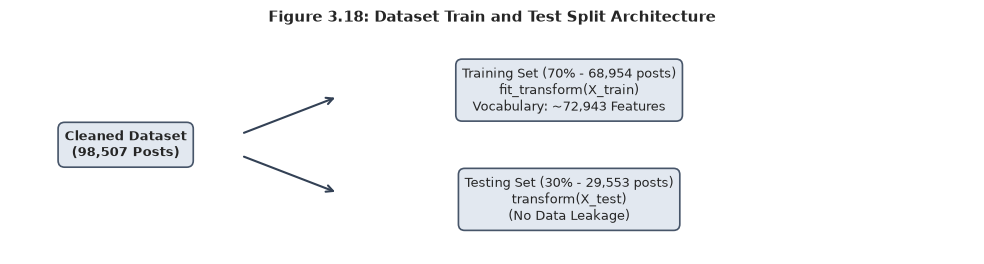

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df['clean_text'], df[target_cols], test_size=0.30, random_state=42
)

printmd(f"**Dataset Partition:** Training set: `{len(X_train):,}` samples ({len(X_train)/len(df)*100:.1f}%), Testing set: `{len(X_test):,}` samples ({len(X_test)/len(df)*100:.1f}%)")

printmd("#### Figure 3.18: Dataset Train and Test Split Architecture")
fig, ax = plt.subplots(figsize=(10, 2.8))
ax.axis('off')

bbox_clean = dict(boxstyle='round,pad=0.5', facecolor='#e2e8f0', edgecolor='#475569', lw=1.2)
bbox_train = dict(boxstyle='round,pad=0.5', facecolor='#e2e8f0', edgecolor='#475569', lw=1.2)
bbox_test = dict(boxstyle='round,pad=0.5', facecolor='#e2e8f0', edgecolor='#475569', lw=1.2)
    
ax.text(0.12, 0.5, f"Cleaned Dataset\n({len(df):,} Posts)", ha='center', va='center', bbox=bbox_clean, fontsize=9.5, fontweight='bold')
ax.annotate("", xy=(0.34, 0.72), xytext=(0.24, 0.55), arrowprops=dict(arrowstyle="->", lw=1.5, color='#334155'))
ax.annotate("", xy=(0.34, 0.28), xytext=(0.24, 0.45), arrowprops=dict(arrowstyle="->", lw=1.5, color='#334155'))

ax.text(0.58, 0.75, f"Training Set (70% - {len(X_train):,} posts)\nfit_transform(X_train)\nVocabulary: ~72,943 Features", ha='center', va='center', bbox=bbox_train, fontsize=9)
ax.text(0.58, 0.25, f"Testing Set (30% - {len(X_test):,} posts)\ntransform(X_test)\n(No Data Leakage)", ha='center', va='center', bbox=bbox_test, fontsize=9)

plt.title("Figure 3.18: Dataset Train and Test Split Architecture", fontsize=11, fontweight='bold', pad=10)
plt.tight_layout()
plt.show()

# Step 17.1: Multi-Label One-vs-Rest (OvR) Binary Decomposition Architecture
### Figure 3.19: One-vs-Rest (OvR) Binary Decomposition Architecture for Multi-Label Classification
Diagram showing how a single vectorized forum post is routed concurrently to 6 independent binary classifiers, producing a combined multi-label prediction set.

#### Figure 3.19: Multi-Label One-vs-Rest (OvR) Binary Decomposition Architecture

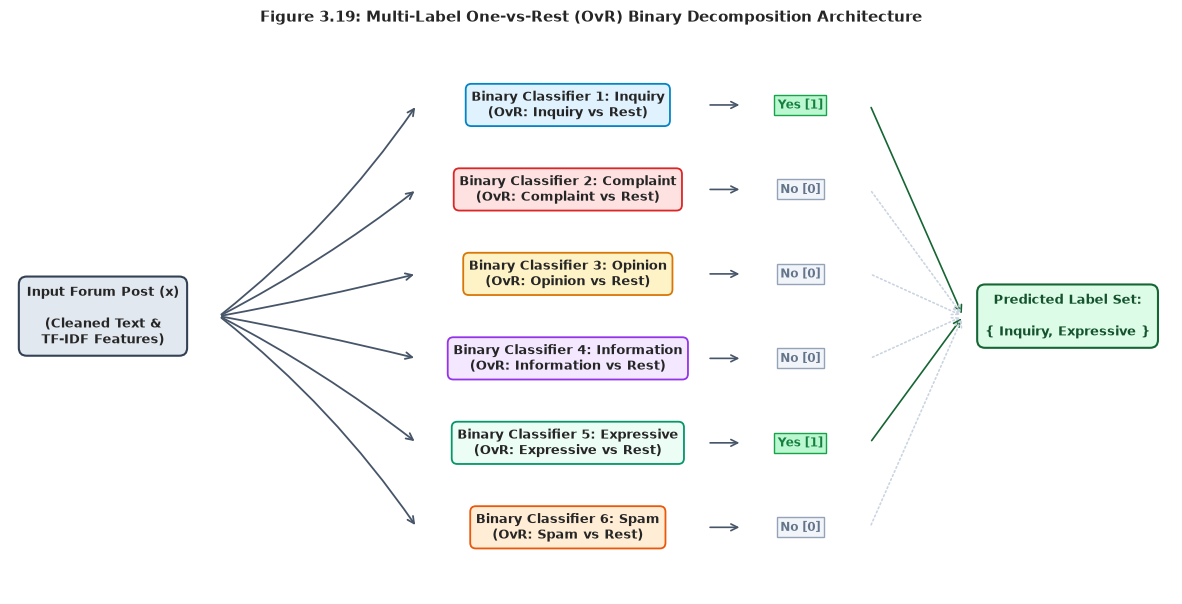

In [29]:
printmd("#### Figure 3.19: Multi-Label One-vs-Rest (OvR) Binary Decomposition Architecture")
fig, ax = plt.subplots(figsize=(12, 6.2))
ax.axis('off')

# Boxes styling
bbox_input = dict(boxstyle='round,pad=0.6', facecolor='#e2e8f0', edgecolor='#334155', lw=1.5)
bbox_output = dict(boxstyle='round,pad=0.6', facecolor='#dcfce7', edgecolor='#166534', lw=1.5)

# Draw Input Post
ax.text(0.08, 0.5, "Input Forum Post (x)\n\n(Cleaned Text &\nTF-IDF Features)", ha='center', va='center', bbox=bbox_input, fontsize=9.5, fontweight='bold')

# Categories & Colors
categories = ['Inquiry', 'Complaint', 'Opinion', 'Information', 'Expressive', 'Spam']
y_positions = np.linspace(0.88, 0.12, 6)
colors = ['#e0f2fe', '#fee2e2', '#fef3c7', '#f3e8ff', '#ecfdf5', '#ffedd5']
edge_colors = ['#0284c7', '#dc2626', '#d97706', '#9333ea', '#059669', '#ea580c']

for i, (cat, y_pos, bg, edge) in enumerate(zip(categories, y_positions, colors, edge_colors)):
    bbox_clf = dict(boxstyle='round,pad=0.45', facecolor=bg, edgecolor=edge, lw=1.3)
    
    # Draw Classifier Box
    ax.text(0.48, y_pos, f"Binary Classifier {i+1}: {cat}\n(OvR: {cat} vs Rest)", ha='center', va='center', bbox=bbox_clf, fontsize=9, fontweight='bold')
    
    # Arrow from Input to Classifier
    ax.annotate("", xy=(0.35, y_pos), xytext=(0.18, 0.5), arrowprops=dict(arrowstyle="->", lw=1.3, color='#475569', connectionstyle="arc3,rad=" + str((y_pos - 0.5)*0.2)))
    
    # Decision / Output Tag
    sample_decision = "Yes [1]" if cat in ['Inquiry', 'Expressive'] else "No [0]"
    badge_bg = '#bbf7d0' if "Yes" in sample_decision else '#f1f5f9'
    badge_edge = '#16a34a' if "Yes" in sample_decision else '#94a3b8'
    bbox_ans = dict(boxstyle='square,pad=0.3', facecolor=badge_bg, edgecolor=badge_edge, lw=1)
    ax.text(0.68, y_pos, sample_decision, ha='center', va='center', bbox=bbox_ans, fontsize=8.5, fontweight='bold', color='#15803d' if "Yes" in sample_decision else '#64748b')
    
    # Arrow from Classifier to Decision Tag
    ax.annotate("", xy=(0.63, y_pos), xytext=(0.60, y_pos), arrowprops=dict(arrowstyle="->", lw=1.2, color='#475569'))
    
    # Arrow from Decision Tag to Final Output
    ax.annotate("", xy=(0.82, 0.5), xytext=(0.74, y_pos), arrowprops=dict(arrowstyle="->", lw=1.2, color='#166534' if "Yes" in sample_decision else '#cbd5e1', linestyle='-' if "Yes" in sample_decision else ':'))

# Draw Final Output
ax.text(0.91, 0.5, "Predicted Label Set:\n\n{ Inquiry, Expressive }", ha='center', va='center', bbox=bbox_output, fontsize=9.5, fontweight='bold', color='#14532d')

plt.title("Multi-Label One-vs-Rest (OvR) Binary Decomposition Architecture", fontsize=11, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

# Step 18: TF-IDF Feature Vectorization
### Figure 3.17: Sample Document TF-IDF Feature Weights
Converts cleaned text into numerical n-gram feature vectors weighted by Term Frequency-Inverse Document Frequency (TF-IDF).

In [30]:
from joblib import dump as joblib_dump, load as joblib_load
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words=None, min_df=3, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)
tfidf_vectorizer = tfidf

# Persist TF-IDF vectorizer artifact
joblib_dump(tfidf, "tfidf_vectorizer.joblib")
feature_names = tfidf.get_feature_names_out()
printmd(f"**TF-IDF Vocabulary Space:** Fitted `{len(feature_names):,}` unique n-gram features across `{X_train_tfidf.shape[0]:,}` training documents.")

# Extract sample top weighted terms per document using real dataset primary key (id)
sample_rows = df.head(5)
sample_tfidf_matrix = tfidf.transform(sample_rows['clean_text']).toarray()

top_terms_summary = []
for i in range(len(sample_rows)):
    row_vec = sample_tfidf_matrix[i]
    top_word_indices = np.argsort(row_vec)[-5:][::-1]
    top_word_indices = [idx for idx in top_word_indices if row_vec[idx] > 0]
    top_keywords = ", ".join([f"{mask_unpleasant_words(feature_names[idx])} ({row_vec[idx]:.3f})" for idx in top_word_indices])
    top_terms_summary.append({
        "Row ID": f"Row {int(sample_rows['id'].iloc[i])}",
        "Cleaned Post Text": mask_unpleasant_words(str(sample_rows['clean_text'].iloc[i])[:75]) + ("..." if len(str(sample_rows['clean_text'].iloc[i])) > 75 else ""),
        "Highest TF-IDF Feature Weights": top_keywords
    })

printmd("#### Figure 3.17: Sample Document TF-IDF Feature Weights")
display(pd.DataFrame(top_terms_summary))

**TF-IDF Vocabulary Space:** Fitted `72,060` unique n-gram features across `68,954` training documents.

#### Figure 3.17: Sample Document TF-IDF Feature Weights

,Row ID,Cleaned Post Text,Highest TF-IDF Feature Weights
0,Row 1,feast start,"feast (0.901), start (0.433)"
1,Row 2,shake shake pm urltoken,"shake (0.633), shake pm (0.447), shake shake (0.409), pm urltoken (0.383), pm (0.250)"
2,Row 3,situasi kereta kau hebat hebat kau eh pandu,"hebat (0.576), kau (0.469), hebat hebat (0.371), situasi (0.357), pandu (0.300)"
3,Row 4,currently play india wooh new,"currently (0.577), india (0.571), play (0.435), new (0.389)"
4,Row 5,oi apek bunuh player low health overpass post laugh manada roll floor laugh...,"overpass (0.342), post laugh (0.314), manada (0.312), bunuh (0.306), apek (0.297)"


# Step 19: Train One-vs-Rest Logistic Regression Model
### Figure 3.20: Log Loss Binary Cross-Entropy Formula
$$\mathcal{L}_{\log}(y, p) = -\left[ y \ln(p) + (1 - y) \ln(1 - p) \right]$$

In [31]:
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression

printmd("#### Figure 3.20: Log Loss Binary Cross-Entropy Formula")
printmd(r"$$\mathcal{L}_{\log}(y, p) = -\left[ y \ln(p) + (1 - y) \ln(1 - p) \right]$$")

lr_model = OneVsRestClassifier(LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
lr_model.fit(X_train_tfidf, y_train)
lr_models = lr_model.estimators_

# Persist Logistic Regression model artifact
joblib_dump(lr_model, "logistic_regression_model.joblib")
printmd("**Logistic Regression Model:** Successfully trained and saved to `logistic_regression_model.joblib`.")

#### Figure 3.20: Log Loss Binary Cross-Entropy Formula

$$\mathcal{L}_{\log}(y, p) = -\left[ y \ln(p) + (1 - y) \ln(1 - p) \right]$$

**Logistic Regression Model:** Successfully trained and saved to `logistic_regression_model.joblib`.

# Step 20: Logistic Regression Feature Interpretation & Sigmoid Curves
### Figure 4.6: Top 15 Predictive Features per Category (Logistic Regression) (vulgar terms masked)
### Figure 4.8: Learned Decision Boundary Equations (Logistic Regression) (vulgar terms masked)
### Figure 3.21: Sigmoid Activation Function and Probability Mapping
### Figure 4.5: Calibrated Sigmoid Probability Curves Across All Six Categories

#### Figure 4.6: Top 15 Predictive Features per Category (Logistic Regression) (vulgar terms masked)

,Inquiry,Complaint,Opinion,Information,Expressive,Spam
0,how (12.57),bodoh (7.47),think (7.41),pricetoken (5.51),laugh (22.28),help (8.90)
1,why (9.80),stupid (6.89),bad (5.81),datetoken (4.86),lel (6.31),cash (8.53)
2,what (9.43),s*** (5.41),stupid (5.75),use (3.98),owai (6.16),join (7.82)
3,where (7.59),useless (5.16),like (5.74),pm (3.91),cukur (5.91),urltoken (7.41)
4,which (6.77),complain (5.11),good (5.50),check (3.84),what f*** (5.64),cashout (5.79)
5,want ask (4.42),f*** (4.97),expensive (5.40),yesterday (3.82),f*** (5.60),click (5.34)
6,who (4.02),c**** (4.91),probably (5.05),timetoken (3.57),wow (5.27),reward (5.14)
7,anybody (3.92),b******* (4.77),hard (4.92),yes (3.56),owaii (5.15),group (4.92)
8,how comel (3.78),waste (4.64),maybe (4.88),hujan (3.38),face (4.97),lai (4.75)
9,mean (3.57),damn (4.61),guess (4.66),google (3.36),kekwa (4.64),whatsapp (4.53)


#### Figure 4.8: Learned Decision Boundary Equations (Logistic Regression) (vulgar terms masked)

[Inquiry    ] z = -0.52 + (12.57 * how) + (9.80 * why) + (9.43 * what) + ... + (-3.41 * la) + (-3.84 * laugh)
[Complaint  ] z = -1.43 + (7.47 * bodoh) + (6.89 * stupid) + (5.41 * s***) + ... + (-2.97 * slot) + (-4.90 * urltoken)
[Opinion    ] z = -0.94 + (7.41 * think) + (5.81 * bad) + (5.75 * stupid) + ... + (-5.04 * slot) + (-7.83 * urltoken)
[Information] z = -1.26 + (5.51 * pricetoken) + (4.86 * datetoken) + (3.98 * use) + ... + (-3.85 * why) + (-4.58 * bodoh)
[Expressive ] z = -0.11 + (22.28 * laugh) + (6.31 * lel) + (6.16 * owai) + ... + (-2.88 * remove) + (-5.48 * urltoken)
[Spam       ] z = -3.70 + (8.90 * help) + (8.53 * cash) + (7.82 * join) + ... + (-3.15 * why) + (-3.90 * like)


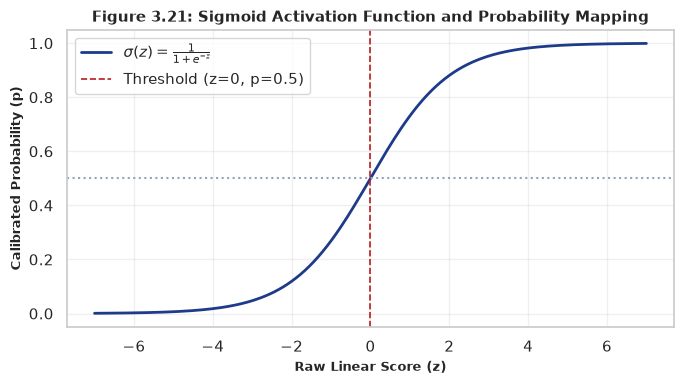

#### Figure 4.5: Calibrated Sigmoid Probability Curves Across All Six Categories

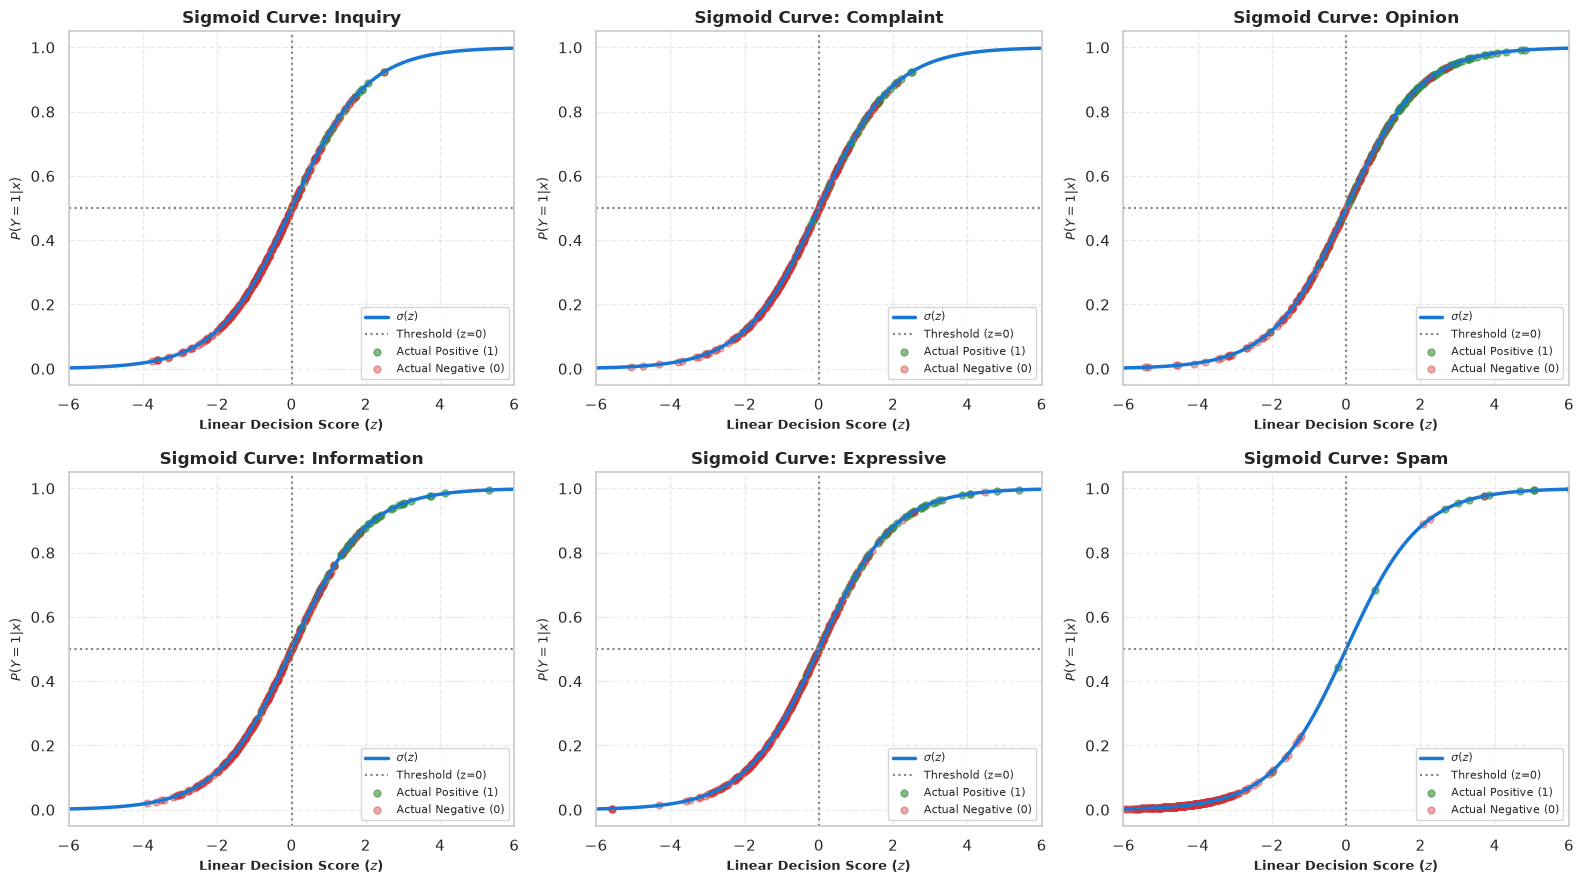

In [32]:
# Feature Coefficients (with vulgar terms masked)
top_words_lr = {}
bottom_words_lr = {}

for i, label in enumerate(target_cols):
    coefs = lr_model.estimators_[i].coef_[0]
    top_indices = np.argsort(coefs)[-15:][::-1]
    bottom_indices = np.argsort(coefs)[:15]
    top_words_lr[label] = [mask_unpleasant_words(f"{feature_names[idx]} ({coefs[idx]:.2f})") for idx in top_indices]
    bottom_words_lr[label] = [mask_unpleasant_words(f"{feature_names[idx]} ({coefs[idx]:.2f})") for idx in bottom_indices]

df_top_words_lr = pd.DataFrame(top_words_lr)
printmd("#### Figure 4.6: Top 15 Predictive Features per Category (Logistic Regression) (vulgar terms masked)")
display(df_top_words_lr)

# Decision Boundary Equations (Showing top 3 positive terms + ... + top 2 negative terms)
def display_decision_boundary_equations_lr(models, feature_names, target_cols):
    printmd("#### Figure 4.8: Learned Decision Boundary Equations (Logistic Regression) (vulgar terms masked)")
    for i, label in enumerate(target_cols):
        est = models[i] if isinstance(models, list) else (models.estimators_[i] if hasattr(models, 'estimators_') else models)
        coefs = est.coef_[0]
        intercept = est.intercept_[0]
        top_3_pos = np.argsort(coefs)[-3:][::-1]
        top_2_neg = np.argsort(coefs)[:2][::-1]
        pos_terms = " + ".join([f"({coefs[idx]:.2f} * {mask_unpleasant_words(feature_names[idx])})" for idx in top_3_pos])
        neg_terms = " + ".join([f"({coefs[idx]:.2f} * {mask_unpleasant_words(feature_names[idx])})" for idx in top_2_neg])
        print(f"[{label:<11}] z = {intercept:.2f} + {pos_terms} + ... + {neg_terms}")

display_decision_boundary_equations_lr(lr_models, feature_names, target_cols)

# Sigmoid 1D Curve
z_vals = np.linspace(-7, 7, 250)
sig_vals = 1 / (1 + np.exp(-z_vals))

plt.figure(figsize=(7, 4))
plt.plot(z_vals, sig_vals, color='#1e3a8a', lw=2, label=r'$\sigma(z) = \frac{1}{1 + e^{-z}}$')
plt.axvline(0, color='#b91c1c', linestyle='--', lw=1.2, label='Threshold (z=0, p=0.5)')
plt.axhline(0.5, color='#94a3b8', linestyle=':')
plt.title("Figure 3.21: Sigmoid Activation Function and Probability Mapping", fontsize=11, fontweight='bold')
plt.xlabel("Raw Linear Score (z)", fontsize=9.5, fontweight='bold')
plt.ylabel("Calibrated Probability (p)", fontsize=9.5, fontweight='bold')
plt.legend(frameon=True)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 6-Category Probability Distribution Curves
def plot_sigmoid_probability_curves(models, X_test, target_cols):
    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    axes = axes.flatten()
    sample_indices = np.random.RandomState(42).choice(X_test.shape[0], size=min(300, X_test.shape[0]), replace=False)
    X_sample = X_test[sample_indices]
    y_test_sample = y_test.iloc[sample_indices]
    
    for i, col in enumerate(target_cols):
        est = models[i] if isinstance(models, list) else (models.estimators_[i] if hasattr(models, 'estimators_') else models)
        coefs = est.coef_[0]
        intercept = est.intercept_[0]
        z_scores = X_sample.dot(coefs) + intercept
        probs = 1 / (1 + np.exp(-z_scores))
        z_curve = np.linspace(-6, 6, 200)
        p_curve = 1 / (1 + np.exp(-z_curve))
        
        axes[i].plot(z_curve, p_curve, color='#1976d2', linewidth=2.5, label=r'$\sigma(z)$')
        axes[i].axvline(0, color='gray', linestyle=':', label='Threshold (z=0)')
        axes[i].axhline(0.5, color='gray', linestyle=':')
        
        true_labels = y_test_sample[col].values
        axes[i].scatter(z_scores[true_labels == 1], probs[true_labels == 1], color='#388e3c', alpha=0.6, s=25, label='Actual Positive (1)')
        axes[i].scatter(z_scores[true_labels == 0], probs[true_labels == 0], color='#d32f2f', alpha=0.4, s=25, label='Actual Negative (0)')
        
        axes[i].set_title(f"Sigmoid Curve: {col}", fontsize=12, fontweight='bold')
        axes[i].set_xlabel("Linear Decision Score ($z$)", fontsize=9.5, fontweight='bold')
        axes[i].set_ylabel(r"$P(Y=1|x)$", fontsize=9.5, fontweight='bold')
        axes[i].set_xlim(-6, 6)
        axes[i].set_ylim(-0.05, 1.05)
        axes[i].legend(loc='lower right', fontsize=8)
        axes[i].grid(True, linestyle='--', alpha=0.4)
        
    plt.tight_layout()
    plt.show()

printmd("#### Figure 4.5: Calibrated Sigmoid Probability Curves Across All Six Categories")
plot_sigmoid_probability_curves(lr_models, X_test_tfidf, target_cols)

# Step 21: Logistic Regression Threshold Tuning, Evaluation & Confusion Matrix
### Figure 3.25: Binary Confusion Matrix Template Layout
### Figure 3.26: Mathematical Formulas for Evaluation Metrics
### Figure 4.2: Logistic Regression Confusion Matrices

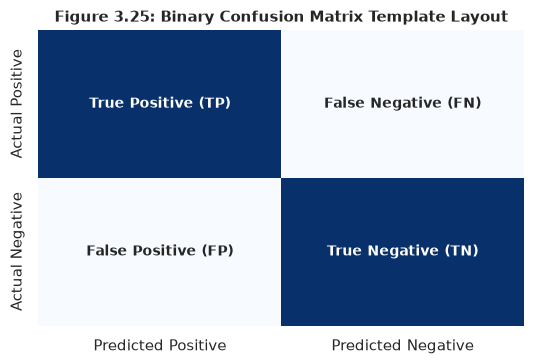

#### Figure 3.26: Mathematical Formulas for Evaluation Metrics


$$\text{Accuracy} = \frac{\text{TP} + \text{TN}}{\text{TP} + \text{TN} + \text{FP} + \text{FN}}, \quad \text{Precision} = \frac{\text{TP}}{\text{TP} + \text{FP}}$$
$$\text{Recall} = \frac{\text{TP}}{\text{TP} + \text{FN}}, \quad \text{F1 Score} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$


#### Classification Report for Logistic Regression:

,Intent Category,Accuracy,Precision,Recall,F1-Score
0,Inquiry,0.7674,0.4791,0.6211,0.5409
1,Complaint,0.7562,0.5130,0.7161,0.5978
2,Opinion,0.7841,0.7700,0.9132,0.8355
3,Information,0.7627,0.6280,0.7530,0.6848
4,Expressive,0.7930,0.5890,0.7650,0.6656
5,Spam,0.9782,0.7107,0.9336,0.8071
6,MACRO AVERAGE,0.8069,0.6150,0.7837,0.6886


#### Figure 4.2: Logistic Regression Confusion Matrices

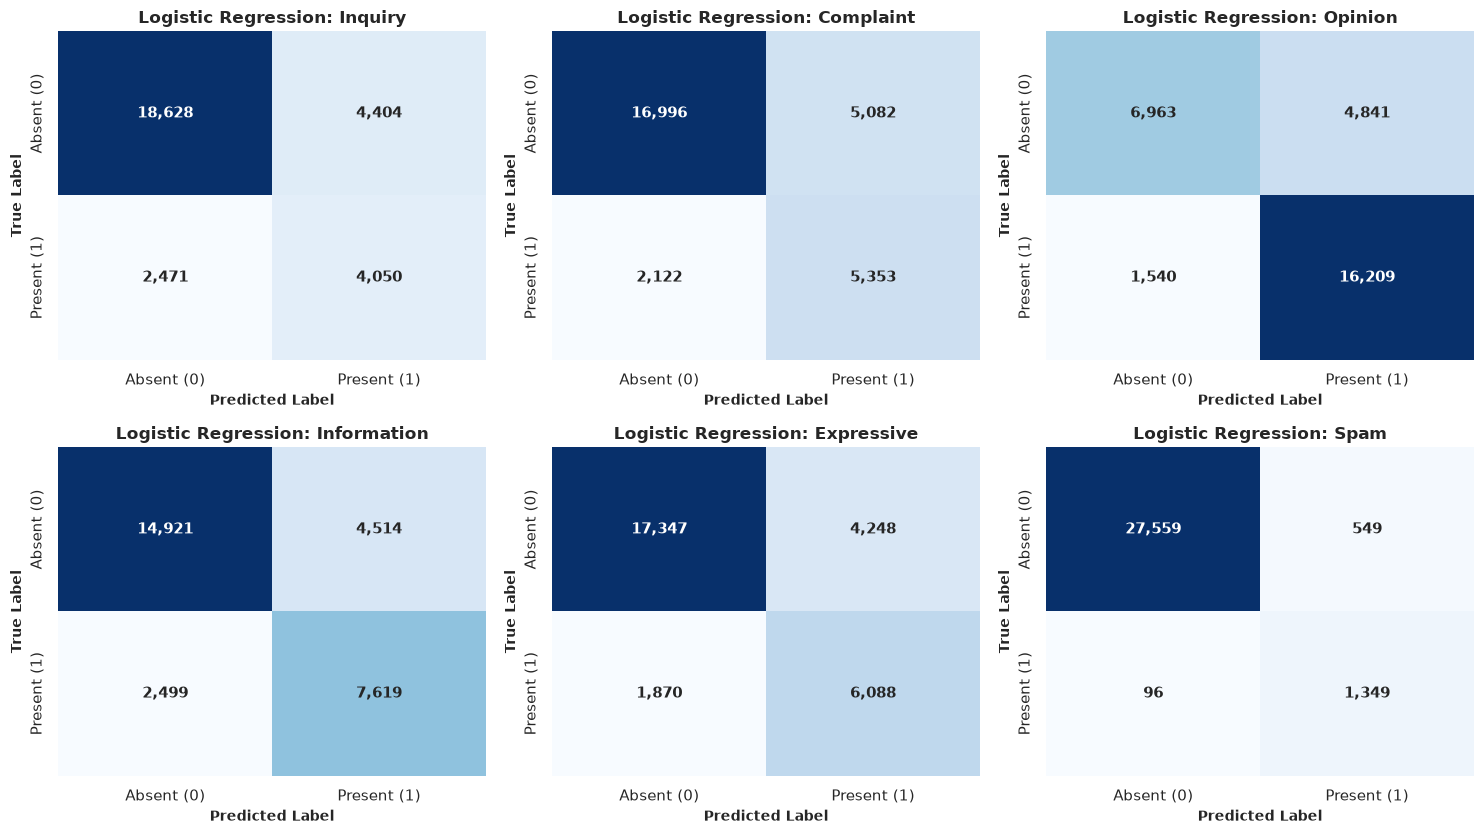

In [33]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Confusion Matrix Template Layout
matrix_layout = [["True Positive (TP)", "False Negative (FN)"],
                 ["False Positive (FP)", "True Negative (TN)"]]

plt.figure(figsize=(5.5, 3.8))
sns.heatmap([[1, 0], [0, 1]], annot=matrix_layout, fmt="", cmap="Blues", cbar=False,
            xticklabels=["Predicted Positive", "Predicted Negative"],
            yticklabels=["Actual Positive", "Actual Negative"],
            annot_kws={'fontsize': 10, 'fontweight': 'bold'})
plt.title("Figure 3.25: Binary Confusion Matrix Template Layout", fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

printmd("#### Figure 3.26: Mathematical Formulas for Evaluation Metrics")
printmd(r"""
$$\text{Accuracy} = \frac{\text{TP} + \text{TN}}{\text{TP} + \text{TN} + \text{FP} + \text{FN}}, \quad \text{Precision} = \frac{\text{TP}}{\text{TP} + \text{FP}}$$
$$\text{Recall} = \frac{\text{TP}}{\text{TP} + \text{FN}}, \quad \text{F1 Score} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$
""")

# Threshold tuning for optimal F1-score
lr_probs_test = lr_model.predict_proba(X_test_tfidf)
lr_best_thresholds = {}
for i, col in enumerate(target_cols):
    best_thresh, best_f1 = 0.5, 0.0
    for thresh in np.arange(0.2, 0.8, 0.02):
        f1 = f1_score(y_test[col], (lr_probs_test[:, i] >= thresh).astype(int), zero_division=0)
        if f1 > best_f1:
            best_f1, best_thresh = f1, thresh
    lr_best_thresholds[col] = best_thresh

y_pred_lr = np.zeros_like(lr_probs_test)
for i, col in enumerate(target_cols):
    y_pred_lr[:, i] = (lr_probs_test[:, i] >= lr_best_thresholds[col]).astype(int)

# Compute Logistic Regression Classification Report
lr_report_data = []
for i, col in enumerate(target_cols):
    acc = accuracy_score(y_test[col], y_pred_lr[:, i])
    prec = precision_score(y_test[col], y_pred_lr[:, i], zero_division=0)
    rec = recall_score(y_test[col], y_pred_lr[:, i], zero_division=0)
    f1 = f1_score(y_test[col], y_pred_lr[:, i], zero_division=0)
    lr_report_data.append({'Intent Category': col, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1})

lr_report_df = pd.DataFrame(lr_report_data)
lr_macro = pd.DataFrame([{
    'Intent Category': 'MACRO AVERAGE',
    'Accuracy': lr_report_df['Accuracy'].mean(),
    'Precision': lr_report_df['Precision'].mean(),
    'Recall': lr_report_df['Recall'].mean(),
    'F1-Score': lr_report_df['F1-Score'].mean()
}])
lr_report_df = pd.concat([lr_report_df, lr_macro], ignore_index=True)
printmd("#### Classification Report for Logistic Regression:")
display(lr_report_df.style.format({'Accuracy': '{:.4f}', 'Precision': '{:.4f}', 'Recall': '{:.4f}', 'F1-Score': '{:.4f}'}))

# Plot Confusion Matrices
def plot_logistic_regression_confusion_matrices(y_true, y_pred, target_cols):
    fig, axes = plt.subplots(2, 3, figsize=(15, 8.5))
    axes = axes.flatten()
    for i, col in enumerate(target_cols):
        y_true_col = y_true[col].values if hasattr(y_true, col) else y_true[:, i]
        y_pred_col = y_pred[:, i] if isinstance(y_pred, np.ndarray) else y_pred[col].values
        cm = confusion_matrix(y_true_col, y_pred_col)
        sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', ax=axes[i], cbar=False,
                    annot_kws={"size": 11, "fontweight": "bold"},
                    xticklabels=['Absent (0)', 'Present (1)'],
                    yticklabels=['Absent (0)', 'Present (1)'])
        axes[i].set_title(f"Logistic Regression: {col}", fontsize=12, fontweight='bold')
        axes[i].set_xlabel("Predicted Label", fontsize=10, fontweight='bold')
        axes[i].set_ylabel("True Label", fontsize=10, fontweight='bold')
    plt.tight_layout()
    plt.show()

printmd("#### Figure 4.2: Logistic Regression Confusion Matrices")
plot_logistic_regression_confusion_matrices(y_test, y_pred_lr, target_cols)

# Step 22: Train One-vs-Rest Linear Support Vector Classifier (Linear SVC) Model
### Figure 3.22: Linear Support Vector Classifier (Linear SVC) Optimization Objective Formula
$$\min_{\mathbf{w}, b} \frac{1}{2} \|\mathbf{w}\|^2 + C \sum_{i=1}^{N} \max\left(0, 1 - y_i(\mathbf{w}^T \mathbf{x}_i + b)\right)$$

### Figure 3.23: Hinge Loss Formula
$$\mathcal{L}_{\text{hinge}}(y, \hat{y}) = \max(0, 1 - y \cdot \hat{y})$$

In [34]:
from sklearn.svm import LinearSVC

printmd("#### Figure 3.22: Linear SVC Optimization Objective Formula")
printmd(r"$$\min_{\mathbf{w}, b} \frac{1}{2} \|\mathbf{w}\|^2 + C \sum_{i=1}^{N} \max\left(0, 1 - y_i(\mathbf{w}^T \mathbf{x}_i + b)\right)$$")

printmd("#### Figure 3.23: Hinge Loss Formula")
printmd(r"$$\mathcal{L}_{\text{hinge}}(y, \hat{y}) = \max(0, 1 - y \cdot \hat{y})$$")

svc_model = OneVsRestClassifier(LinearSVC(class_weight='balanced', max_iter=2000, random_state=42))
svc_model.fit(X_train_tfidf, y_train)
svc_models = svc_model.estimators_

# Persist Linear SVC model artifact
joblib_dump(svc_model, "linear_svc_model.joblib")
printmd("**Linear SVC Model:** Successfully trained and saved to `linear_svc_model.joblib`.")

#### Figure 3.22: Linear SVC Optimization Objective Formula

$$\min_{\mathbf{w}, b} \frac{1}{2} \|\mathbf{w}\|^2 + C \sum_{i=1}^{N} \max\left(0, 1 - y_i(\mathbf{w}^T \mathbf{x}_i + b)\right)$$

#### Figure 3.23: Hinge Loss Formula

$$\mathcal{L}_{\text{hinge}}(y, \hat{y}) = \max(0, 1 - y \cdot \hat{y})$$

**Linear SVC Model:** Successfully trained and saved to `linear_svc_model.joblib`.

# Step 23: Linear SVC Feature Interpretation, Hyperplane & Prediction Rule
### Figure 4.7: Top 15 Predictive Features per Category (Linear SVC) (vulgar terms masked)
### Figure 4.9: Learned Decision Boundary Equations (Linear SVC) (vulgar terms masked)
### Figure 3.24: Linear SVC Margin and Hyperplane (Conceptual 2D)

#### Figure 4.7: Top 15 Predictive Features per Category (Linear SVC) (vulgar terms masked)

,Inquiry,Complaint,Opinion,Information,Expressive,Spam
0,how (5.57),stupid (3.44),think (3.74),iinm (2.65),laugh (9.60),urltoken mari (2.37)
1,why (4.01),overprice (3.40),useless (3.13),injured (2.47),cukur (3.71),find account (2.10)
2,what (3.68),f***** (2.98),bad (3.06),datetoken (2.43),lel (3.61),luck urltoken (2.08)
3,want ask (3.37),useless (2.90),expensive (2.97),starter urltoken (2.29),owaii (3.44),urltoken new (2.04)
4,which (3.29),haiz (2.88),hard (2.74),s*** urltoken (2.27),kekwa (3.26),urltoken (2.04)
5,where (3.28),adu (2.86),b******* (2.70),pesticide (2.23),owai (3.25),live la (2.02)
6,correct wrong (2.77),complain (2.86),imagine (2.54),season start (2.21),kekk (3.24),betting (1.99)
7,curious (2.73),sigh (2.80),maybe (2.52),who urltoken (2.21),fuh (3.14),need thank (1.97)
8,anybody (2.66),bodoh (2.71),probably (2.50),thread urltoken (2.17),what f*** (3.09),urltoken shopee (1.92)
9,regain (2.58),b******* (2.68),ugly (2.49),ryzen (2.16),yay (2.99),urltoken fast (1.89)


#### Figure 4.9: Learned Decision Boundary Equations (Linear SVC) (vulgar terms masked)

[Inquiry    ] z = -0.37 + (5.57 * how) + (4.01 * why) + (3.68 * what) + ... + (-2.45 * know how) + (-2.60 * matter how)
[Complaint  ] z = -0.93 + (3.44 * stupid) + (3.40 * overprice) + (2.98 * f*****) + ... + (-1.98 * professor) + (-2.00 * realme)
[Opinion    ] z = -0.57 + (3.74 * think) + (3.13 * useless) + (3.06 * bad) + ... + (-2.17 * urltoken) + (-2.26 * bother look)
[Information] z = -0.76 + (2.65 * iinm) + (2.47 * injured) + (2.43 * datetoken) + ... + (-2.15 * bodoh) + (-2.18 * ridiculous)
[Expressive ] z = -0.16 + (9.60 * laugh) + (3.71 * cukur) + (3.61 * lel) + ... + (-2.28 * laugh face) + (-2.32 * oos laugh)
[Spam       ] z = -1.10 + (2.37 * urltoken mari) + (2.10 * find account) + (2.08 * luck urltoken) + ... + (-1.41 * good) + (-1.57 * group thanks)


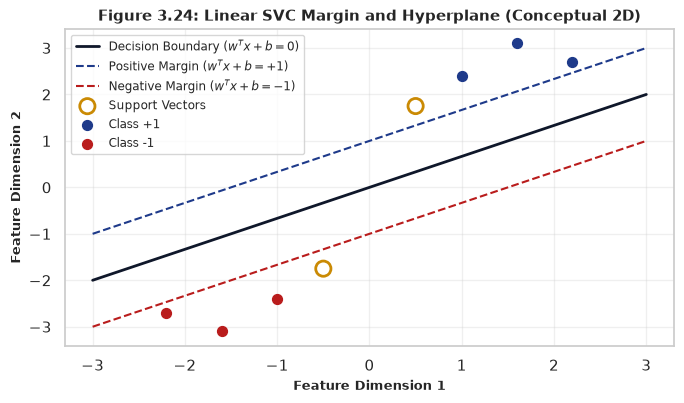

In [35]:
# Feature Coefficients (with vulgar terms masked)
top_words_svc = {}
bottom_words_svc = {}

for i, label in enumerate(target_cols):
    coefs = svc_model.estimators_[i].coef_[0]
    top_indices = np.argsort(coefs)[-15:][::-1]
    bottom_indices = np.argsort(coefs)[:15]
    top_words_svc[label] = [mask_unpleasant_words(f"{feature_names[idx]} ({coefs[idx]:.2f})") for idx in top_indices]
    bottom_words_svc[label] = [mask_unpleasant_words(f"{feature_names[idx]} ({coefs[idx]:.2f})") for idx in bottom_indices]
    
df_top_words_svc = pd.DataFrame(top_words_svc)
printmd("#### Figure 4.7: Top 15 Predictive Features per Category (Linear SVC) (vulgar terms masked)")
display(df_top_words_svc)

# Decision Boundary Equations (Showing top 3 positive terms + ... + top 2 negative terms)
def display_decision_boundary_equations_svc(models, feature_names, target_cols):
    printmd("#### Figure 4.9: Learned Decision Boundary Equations (Linear SVC) (vulgar terms masked)")
    for i, label in enumerate(target_cols):
        est = models[i] if isinstance(models, list) else (models.estimators_[i] if hasattr(models, 'estimators_') else models)
        coefs = est.coef_[0]
        intercept = est.intercept_[0]
        top_3_pos = np.argsort(coefs)[-3:][::-1]
        top_2_neg = np.argsort(coefs)[:2][::-1]
        pos_terms = " + ".join([f"({coefs[idx]:.2f} * {mask_unpleasant_words(feature_names[idx])})" for idx in top_3_pos])
        neg_terms = " + ".join([f"({coefs[idx]:.2f} * {mask_unpleasant_words(feature_names[idx])})" for idx in top_2_neg])
        print(f"[{label:<11}] z = {intercept:.2f} + {pos_terms} + ... + {neg_terms}")

display_decision_boundary_equations_svc(svc_models, feature_names, target_cols)

# Margin and Hyperplane
plt.figure(figsize=(7, 4.2))
plt.plot([-3, 3], [-2, 2], color='#0f172a', lw=2, label='Decision Boundary ($w^T x + b = 0$)')
plt.plot([-3, 3], [-1, 3], color='#1e3a8a', linestyle='--', label='Positive Margin ($w^T x + b = +1$)')
plt.plot([-3, 3], [-3, 1], color='#b91c1c', linestyle='--', label='Negative Margin ($w^T x + b = -1$)')
    
plt.scatter([0.5, -0.5], [1.75, -1.75], s=120, facecolors='none', edgecolors='#ca8a04', lw=2, label='Support Vectors', zorder=5)
plt.scatter([1, 1.6, 2.2], [2.4, 3.1, 2.7], color='#1e3a8a', s=50, label='Class +1')
plt.scatter([-1, -1.6, -2.2], [-2.4, -3.1, -2.7], color='#b91c1c', s=50, label='Class -1')

plt.title("Figure 3.24: Linear SVC Margin and Hyperplane (Conceptual 2D)", fontsize=11, fontweight='bold')
plt.xlabel("Feature Dimension 1", fontsize=9.5, fontweight='bold')
plt.ylabel("Feature Dimension 2", fontsize=9.5, fontweight='bold')
plt.legend(loc='upper left', fontsize=8.5, frameon=True)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Step 24: Linear SVC Evaluation & Confusion Matrix
### Figure 4.3: Linear SVC Confusion Matrices

#### Classification Report for Linear SVC:

,Intent Category,Accuracy,Precision,Recall,F1-Score
0,Inquiry,0.7537,0.4537,0.5697,0.5051
1,Complaint,0.7628,0.5256,0.6400,0.5772
2,Opinion,0.7726,0.8245,0.7895,0.8066
3,Information,0.7574,0.6322,0.6969,0.6630
4,Expressive,0.7947,0.6079,0.6693,0.6371
5,Spam,0.9772,0.6969,0.9453,0.8023
6,MACRO AVERAGE,0.8031,0.6235,0.7184,0.6652


#### Figure 4.3: Linear SVC Confusion Matrices

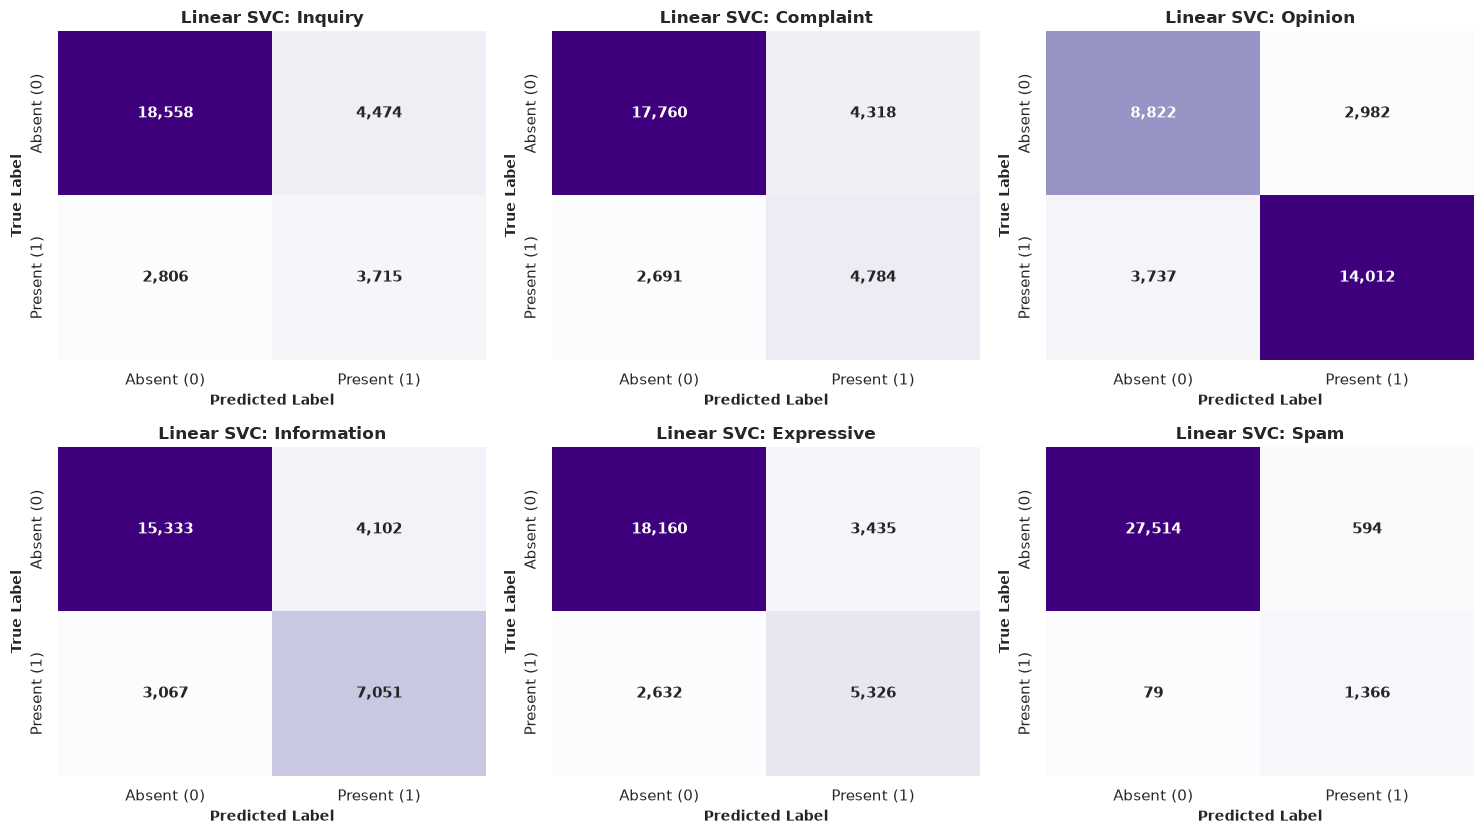

In [36]:
y_pred_svc = svc_model.predict(X_test_tfidf)

# Compute Linear SVC Classification Report
svc_report_data = []
for i, col in enumerate(target_cols):
    acc = accuracy_score(y_test[col], y_pred_svc[:, i])
    prec = precision_score(y_test[col], y_pred_svc[:, i], zero_division=0)
    rec = recall_score(y_test[col], y_pred_svc[:, i], zero_division=0)
    f1 = f1_score(y_test[col], y_pred_svc[:, i], zero_division=0)
    svc_report_data.append({'Intent Category': col, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1})

svc_report_df = pd.DataFrame(svc_report_data)
svc_macro = pd.DataFrame([{
    'Intent Category': 'MACRO AVERAGE',
    'Accuracy': svc_report_df['Accuracy'].mean(),
    'Precision': svc_report_df['Precision'].mean(),
    'Recall': svc_report_df['Recall'].mean(),
    'F1-Score': svc_report_df['F1-Score'].mean()
}])
svc_report_df = pd.concat([svc_report_df, svc_macro], ignore_index=True)
printmd("#### Classification Report for Linear SVC:")
display(svc_report_df.style.format({'Accuracy': '{:.4f}', 'Precision': '{:.4f}', 'Recall': '{:.4f}', 'F1-Score': '{:.4f}'}))

# Plot Confusion Matrices
def plot_linear_svc_confusion_matrices(y_true, y_pred, target_cols):
    fig, axes = plt.subplots(2, 3, figsize=(15, 8.5))
    axes = axes.flatten()
    for i, col in enumerate(target_cols):
        y_true_col = y_true[col].values if hasattr(y_true, col) else y_true[:, i]
        y_pred_col = y_pred[:, i] if isinstance(y_pred, np.ndarray) else y_pred[col].values
        cm = confusion_matrix(y_true_col, y_pred_col)
        sns.heatmap(cm, annot=True, fmt=',d', cmap='Purples', ax=axes[i], cbar=False,
                    annot_kws={"size": 11, "fontweight": "bold"},
                    xticklabels=['Absent (0)', 'Present (1)'],
                    yticklabels=['Absent (0)', 'Present (1)'])
        axes[i].set_title(f"Linear SVC: {col}", fontsize=12, fontweight='bold')
        axes[i].set_xlabel("Predicted Label", fontsize=10, fontweight='bold')
        axes[i].set_ylabel("True Label", fontsize=10, fontweight='bold')
    plt.tight_layout()
    plt.show()

printmd("#### Figure 4.3: Linear SVC Confusion Matrices")
plot_linear_svc_confusion_matrices(y_test, y_pred_svc, target_cols)

# Step 25: Side-by-Side Model Comparison (Logistic Regression vs Linear SVC)
### Figure 4.1: Overall Performance Comparison Table
### Figure 4.4: Comparative Bar Charts Across Communicative Categories

#### Figure 4.1: Overall Performance Comparison Table

,LR_Accuracy,SVC_Accuracy,LR_Precision,SVC_Precision,LR_Recall,SVC_Recall,LR_F1-Score,SVC_F1-Score
Intent Category,,,,,,,,
Inquiry,0.767,0.754,0.479,0.454,0.621,0.570,0.541,0.505
Complaint,0.756,0.763,0.513,0.526,0.716,0.640,0.598,0.577
Opinion,0.784,0.773,0.770,0.825,0.913,0.789,0.836,0.807
Information,0.763,0.757,0.628,0.632,0.753,0.697,0.685,0.663
Expressive,0.793,0.795,0.589,0.608,0.765,0.669,0.666,0.637
Spam,0.978,0.977,0.711,0.697,0.934,0.945,0.807,0.802
MACRO AVERAGE,0.807,0.803,0.615,0.623,0.784,0.718,0.689,0.665


#### Figure 4.4: Comparative Bar Charts Across Communicative Categories

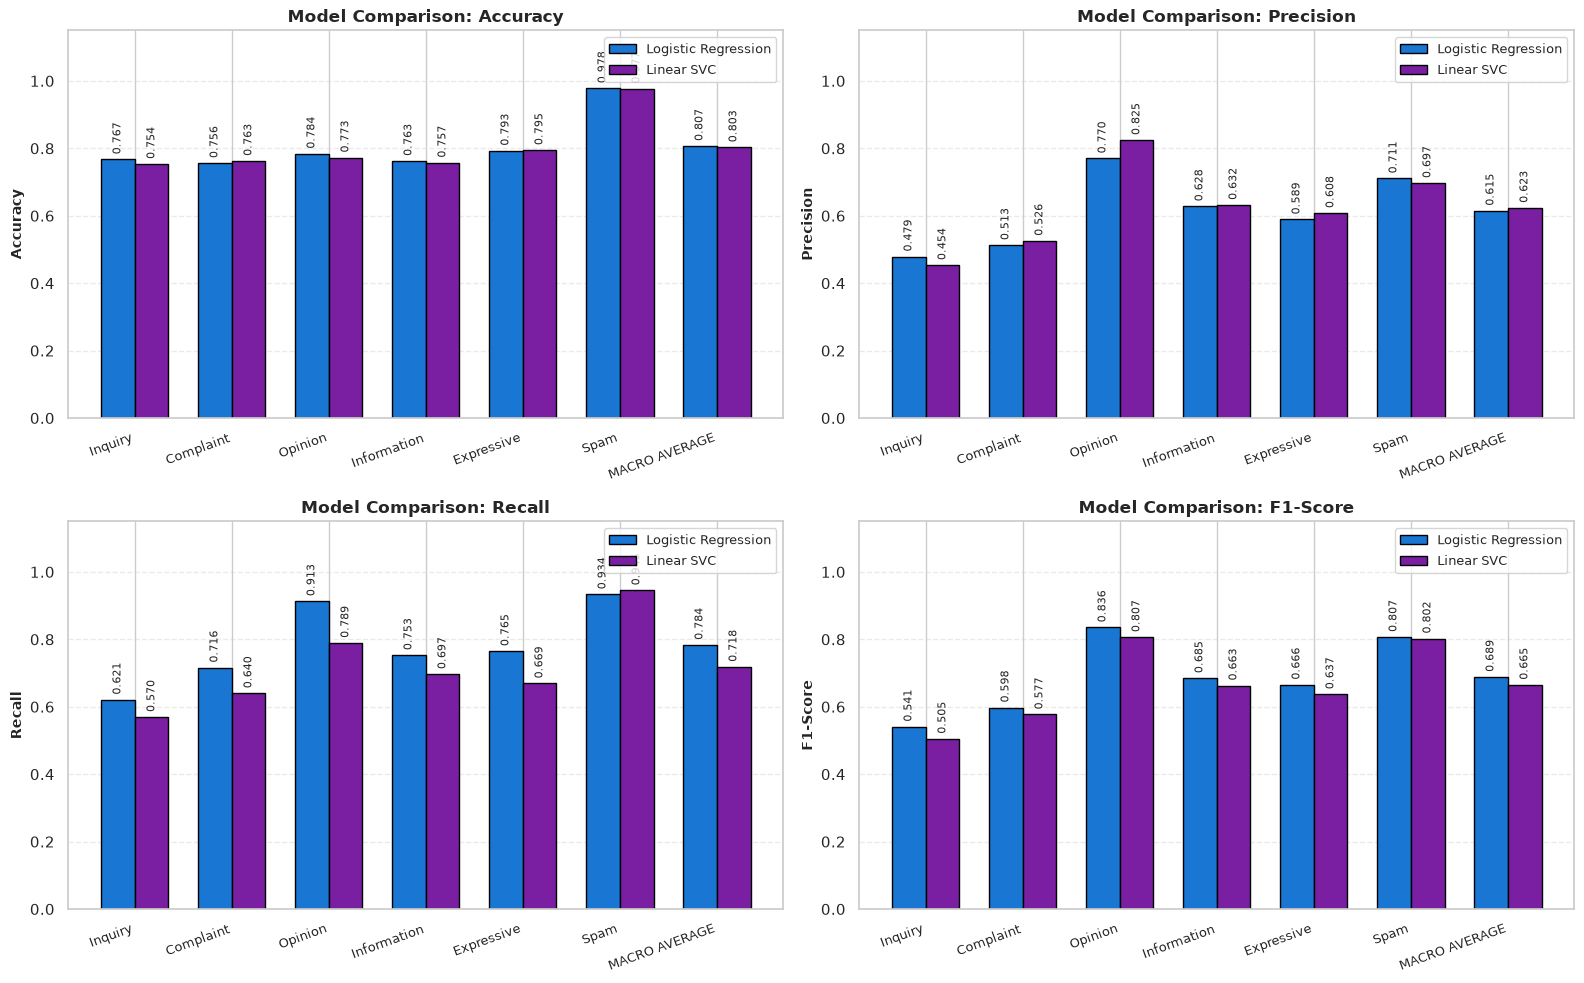

In [37]:
# Construct side-by-side comparison DataFrame
comparison_rows = []
for cat in target_cols + ['MACRO AVERAGE']:
    lr_row = lr_report_df[lr_report_df['Intent Category'] == cat].iloc[0]
    svc_row = svc_report_df[svc_report_df['Intent Category'] == cat].iloc[0]
    comparison_rows.append({
        'Intent Category': cat,
        'LR_Accuracy': lr_row['Accuracy'],
        'SVC_Accuracy': svc_row['Accuracy'],
        'LR_Precision': lr_row['Precision'],
        'SVC_Precision': svc_row['Precision'],
        'LR_Recall': lr_row['Recall'],
        'SVC_Recall': svc_row['Recall'],
        'LR_F1-Score': lr_row['F1-Score'],
        'SVC_F1-Score': svc_row['F1-Score']
    })

df_model_comparison = pd.DataFrame(comparison_rows).set_index('Intent Category')

printmd("#### Figure 4.1: Overall Performance Comparison Table")
display(df_model_comparison.style.format('{:.3f}'))

# Plot comparison bar charts
def plot_model_comparison_bars(comparison_df):
    metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
    categories = target_cols + ['MACRO AVERAGE']
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    axes = axes.flatten()
    x = np.arange(len(categories))
    width = 0.35
    
    for idx, metric in enumerate(metrics):
        lr_vals = [comparison_df.loc[cat, f'LR_{metric}'] for cat in categories]
        svc_vals = [comparison_df.loc[cat, f'SVC_{metric}'] for cat in categories]
        
        rects1 = axes[idx].bar(x - width/2, lr_vals, width, label='Logistic Regression', color='#1976d2', edgecolor='black')
        rects2 = axes[idx].bar(x + width/2, svc_vals, width, label='Linear SVC', color='#7b1fa2', edgecolor='black')
        
        axes[idx].set_title(f"Model Comparison: {metric}", fontsize=12, fontweight='bold')
        axes[idx].set_xticks(x)
        axes[idx].set_xticklabels(categories, rotation=20, ha='right', fontsize=9.5)
        axes[idx].set_ylabel(metric, fontsize=10, fontweight='bold')
        axes[idx].set_ylim(0, 1.15)
        axes[idx].legend(loc='upper right', fontsize=9.5)
        axes[idx].grid(True, linestyle='--', alpha=0.4, axis='y')
        
        for r in rects1:
            h = r.get_height()
            axes[idx].text(r.get_x() + r.get_width()/2., h + 0.015, f"{h:.3f}", ha='center', va='bottom', fontsize=8, rotation=90)
        for r in rects2:
            h = r.get_height()
            axes[idx].text(r.get_x() + r.get_width()/2., h + 0.015, f"{h:.3f}", ha='center', va='bottom', fontsize=8, rotation=90)
            
    plt.tight_layout()
    plt.show()

printmd("#### Figure 4.4: Comparative Bar Charts Across Communicative Categories")
plot_model_comparison_bars(df_model_comparison)

# Step 26: End-to-End Raw Text Preprocessing Pipeline & Model Inference Demo
Packages the full 16-step preprocessing sequence into a single unified callable function `preprocess_pipeline()` and loads saved artifacts.

In [38]:
def preprocess_pipeline(raw_text):
    if not isinstance(raw_text, str) or not raw_text.strip():
        return ""
    
    # Step 1: Remove Quotes, BBCode & Markup
    text = remove_forum_markup(raw_text)
    
    # Step 2: Entity Masking
    text = mask_entities(text)
    
    # Step 3: Normalize Elongations & Laughter
    text = remove_elongated_content(text)
    
    # Step 4: Convert Emojis
    text = convert_emojis(text)
    
    # Step 5: Case & Spacing Normalization
    text = normalize_spacing_and_case(text)
    
    # Step 6: Slang Normalization via compiled master dictionary
    text = normalize_slangs(text)
    
    # Step 7: Expand Contractions
    text = fix_contractions(text)
    
    # Step 8: Remove All Punctuations
    text = remove_punctuations(text)
    
    # Step 9: Split Alphanumeric & Remove Standalone Numbers
    text = split_and_remove_numbers(text)
    
    # Step 10: Remove Non-Latin Characters
    text = remove_non_latin(text)
    
    # Step 11: Word Tokenization
    tokens = tokenize_words(text)
    
    # Step 12: Language Tagging
    tagged = tag_tokens(tokens)
    
    # Step 13: POS Tagging for English Tokens
    pos_tagged = pos_tag_english_tokens(tagged)
    
    # Step 14: Lemmatization & Stemming
    morph_tokens = lemmatize_and_stem(pos_tagged)
    
    # Step 15: Stopword Removal
    filtered = remove_stopwords(morph_tokens)
    
    return ' '.join([t[0] for t in filtered])

# Load serialized artifacts from disk
loaded_tfidf = joblib_load("tfidf_vectorizer.joblib")
loaded_lr = joblib_load("logistic_regression_model.joblib")
loaded_svc = joblib_load("linear_svc_model.joblib")
printmd("**Artifacts Status:** All serialized models (`TF-IDF`, `Logistic Regression`, `Linear SVC`) loaded successfully from disk.")

**Artifacts Status:** All serialized models (`TF-IDF`, `Logistic Regression`, `Linear SVC`) loaded successfully from disk.

# Step 27: Real-Time Prediction on Unseen Posts (Showing Both Models)
Execute real-time multi-label classification on brand-new unseen forum posts, displaying predictions simultaneously from **both Logistic Regression and Linear SVC**.

In [39]:
def format_ranked_badges(ranked_list, is_probability=True):
    if not ranked_list:
        return '<span style="color:#777; font-style:italic; font-size:12px;">Neutral / None</span>'
    
    badges = []
    for idx, (intent, score) in enumerate(ranked_list):
        score_text = f"{score * 100:.1f}%" if is_probability else f"score: {score:+.2f}"
        if idx == 0:
            badges.append(
                f'<span style="background-color:#2e7d32; color:#ffffff; padding: 3px 9px; '
                f'border-radius: 4px; font-weight: bold; font-size: 12px; margin-right: 4px;">'
                f'★ Best: {intent} ({score_text})</span>'
            )
        else:
            badges.append(
                f'<span style="background-color:#e0e0e0; color:#333333; padding: 3px 8px; '
                f'border-radius: 4px; font-weight: 500; font-size: 12px; margin-right: 4px;">'
                f'{intent} ({score_text})</span>'
            )
    return ''.join(badges)

def predict_unseen(raw_text):
    cleaned_input = preprocess_pipeline(raw_text)
    if not cleaned_input.strip():
        return {
            "raw_text": raw_text,
            "cleaned_text": cleaned_input,
            "lr_ranked": [],
            "svc_ranked": []
        }
    
    vectorized_input = loaded_tfidf.transform([cleaned_input])
    
    # Logistic Regression
    lr_probs = loaded_lr.predict_proba(vectorized_input)[0]
    lr_positive = [(target_cols[i], lr_probs[i]) for i in range(len(target_cols)) if lr_probs[i] >= lr_best_thresholds[target_cols[i]]]
    lr_ranked = sorted(lr_positive, key=lambda x: x[1], reverse=True)
    
    # Linear SVC
    svc_scores = loaded_svc.decision_function(vectorized_input)[0]
    svc_preds = loaded_svc.predict(vectorized_input)[0]
    svc_positive = [(target_cols[i], svc_scores[i]) for i, val in enumerate(svc_preds) if val == 1]
    svc_ranked = sorted(svc_positive, key=lambda x: x[1], reverse=True)
    
    return {
        "raw_text": raw_text,
        "cleaned_text": cleaned_input,
        "lr_ranked": lr_ranked,
        "svc_ranked": svc_ranked
    }

# Test sample comment
test_sample = "can you check whether i did it right or not why is it failing"
res = predict_unseen(test_sample)
printmd(f"**Test Prediction Demo on Sample Input:** `{test_sample}`")
display(HTML(f'''
<div style="border: 1px solid #e0e0e0; border-radius: 6px; padding: 12px; margin-top: 10px; background-color: #fafafa;">
    <div style="margin-bottom: 6px;"><strong>Raw Input:</strong> <code style="font-size:12px;">{html.escape(res['raw_text'])}</code></div>
    <div style="margin-bottom: 8px;"><strong>Cleaned Input:</strong> <code style="font-size:12px;">{html.escape(res['cleaned_text'])}</code></div>
    <div style="margin-bottom: 6px;"><strong>Logistic Regression:</strong> {format_ranked_badges(res['lr_ranked'], is_probability=True)}</div>
    <div style="margin-bottom: 6px;"><strong>Linear SVC:</strong> {format_ranked_badges(res['svc_ranked'], is_probability=False)}</div>
</div>
'''))

**Test Prediction Demo on Sample Input:** `can you check whether i did it right or not why is it failing`